<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys"], n)

df_collection["formated_table"].head

<bound method NDFrame.head of                 credit_score          country         gender  \
0          Credit_Score_Fair   Country_France  Gender_Female   
1          Credit_Score_Fair    Country_Spain  Gender_Female   
2          Credit_Score_Poor   Country_France  Gender_Female   
3          Credit_Score_Good   Country_France  Gender_Female   
4     Credit_Score_Excellent    Country_Spain  Gender_Female   
...                      ...              ...            ...   
9995  Credit_Score_Very_Good   Country_France    Gender_Male   
9996       Credit_Score_Poor   Country_France    Gender_Male   
9997       Credit_Score_Good   Country_France  Gender_Female   
9998  Credit_Score_Very_Good  Country_Germany    Gender_Male   
9999  Credit_Score_Very_Good   Country_France  Gender_Female   

                            age     tenure            balance  \
0     Age_Adults_in_their_Prime   Tenure_2  Balance_Cluster_1   
1     Age_Adults_in_their_Prime   Tenure_1  Balance_Cluster_4   
2     

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path

seeds = [1, 42, 66]

trainer = ModelTrainer()
repository = ModelRepository(base_dir=Path.cwd())

models = {}  
categories = {} 

# Führe Experimente durch
for seed in seeds:
    base_config = ModelConfig(
        vector_size = 150,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
        window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
        epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
        min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
        negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
        sample = 1e-3,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
        hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
        alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
        seed = seed,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
    )
    runner = ExperimentRunner(trainer, repository, base_config)
    models[seed], categories[seed] = runner.create_many_models(
        sentences=df_collection["n_sentences"]["20"],
        n_sentences_tokenized=df_collection["n_sentences"],
        n_used_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
        verbose=True
    )
    

Model Creation started.
...Creating sentence models...
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000_sentlen_17_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=150, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_150_win_4_ep_30_nsent_10000_sentlen_17_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000_sentlen_85_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=150, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_150_win_4_ep_30_nsent_10000_sentlen_85_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = {}

for seed in seeds:
    if seed not in average_sentence_vectors:
        average_sentence_vectors[seed] = {}
    for category in categories[seed]:  
        print(f"(-------------Vector calculation of category: {category.upper()}-------------)")
        
        if category not in average_sentence_vectors[seed]:
            average_sentence_vectors[seed][category] = []
        
        for model in models[seed][category]:
            vectors = create_average_sentence_vectors(
                model, 
                df_collection["formated_table_with_keys"], 
                base_dir=Path.cwd(), 
                verbose=False
            )
            average_sentence_vectors[seed][category].append([vectors, model[1]])
        
        print(f"(-------------Finished Vector calculation of category: {category.upper()}-------------)")

(-------------Vector calculation of category: SENTENCE-------------)
(-------------Finished Vector calculation of category: SENTENCE-------------)
(-------------Vector calculation of category: VECTOR-------------)
(-------------Finished Vector calculation of category: VECTOR-------------)
(-------------Vector calculation of category: WINDOWSIZE-------------)
(-------------Finished Vector calculation of category: WINDOWSIZE-------------)
(-------------Vector calculation of category: EPOCH-------------)
(-------------Finished Vector calculation of category: EPOCH-------------)
(-------------Vector calculation of category: SENTENCE-------------)
(-------------Finished Vector calculation of category: SENTENCE-------------)
(-------------Vector calculation of category: VECTOR-------------)
(-------------Finished Vector calculation of category: VECTOR-------------)
(-------------Vector calculation of category: WINDOWSIZE-------------)
(-------------Finished Vector calculation of category: WI

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.collect_test_data import get_all_sweep_results
    
test_results = get_all_sweep_results(average_sentence_vectors, models, df_collection["formated_table_with_keys"] , verbose=False)

(-------------Test of category: SENTENCE-------------)

(-------------Test of category: VECTOR-------------)

(-------------Test of category: WINDOWSIZE-------------)

(-------------Test of category: EPOCH-------------)

Tests abgeschlossen. 130 Modelle getestet.


In [5]:
i=0
#print(test_results)

<h2>Visualisierung<h2>

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

def render_figure(fig, name, dpi=300, show=True):
    """
    Centralized figure handling:
    - saves in publication-quality formats
    - optionally displays in Jupyter
    - closes figure to avoid memory leaks
    """
    fig.savefig(FIGURE_DIR / f"{name}.pdf")
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=dpi)

    if show:
        plt.show()

    plt.close(fig)


WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



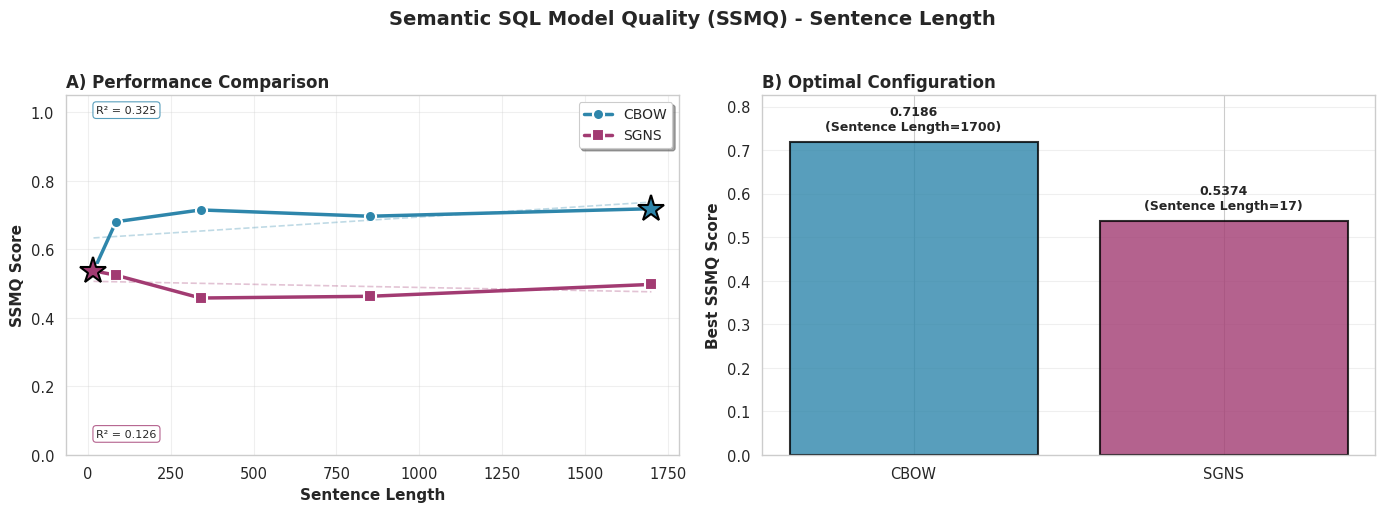

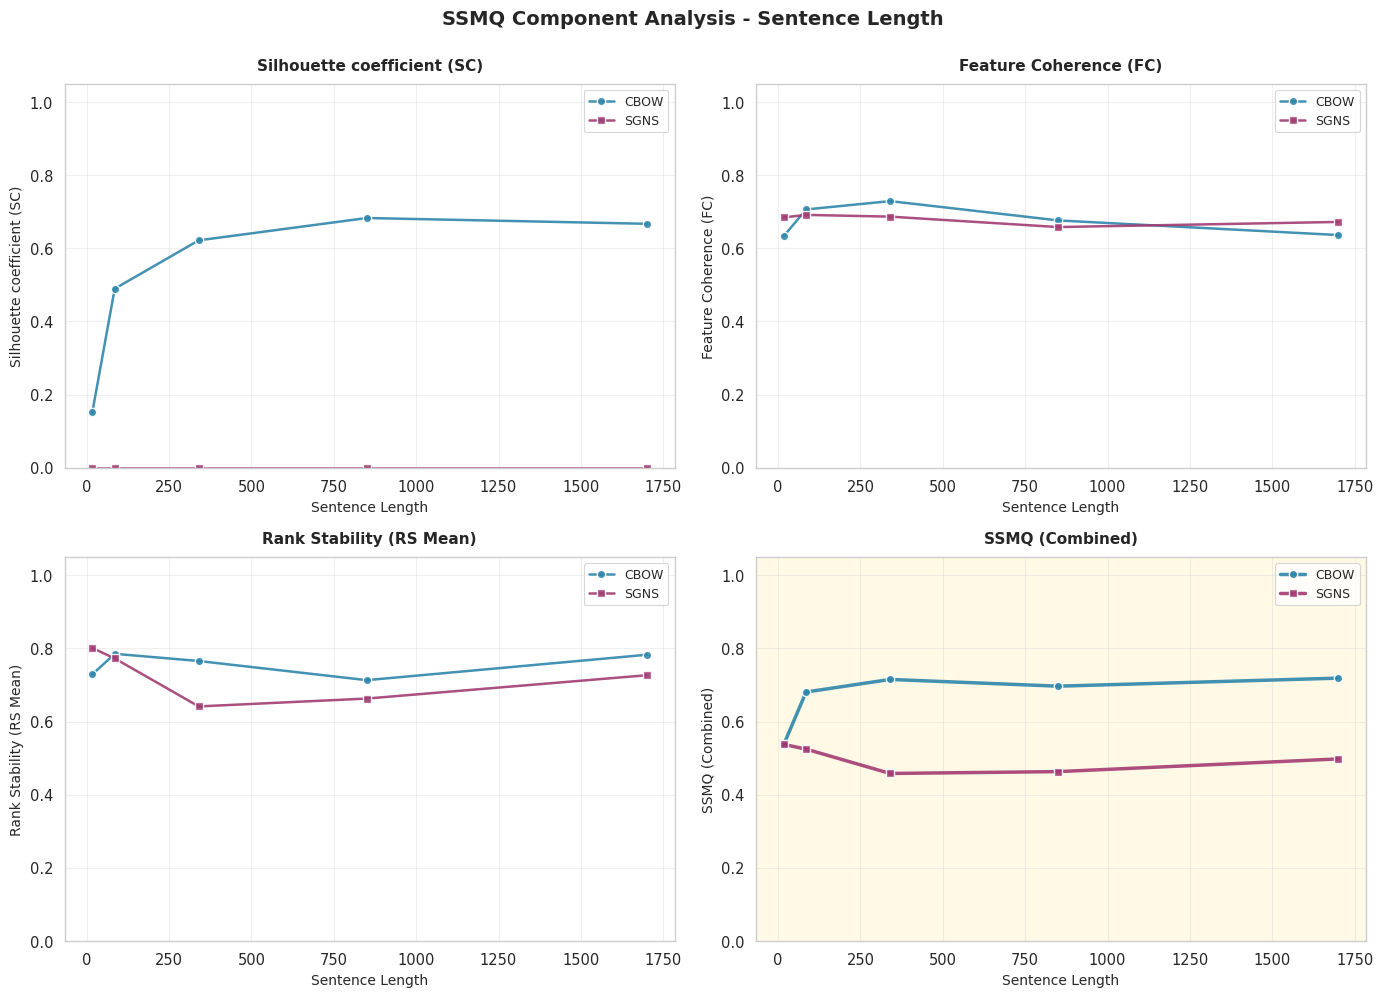


NUMERICAL RESULTS TABLE - SENTENCE

Sentence Length | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
17           | 0.1514    0.6330    0.7289    0.5364    | 0.0000    0.6844    0.8010    0.5374   
85           | 0.4894    0.7062    0.7851    0.6806    | 0.0000    0.6913    0.7725    0.5245   
340          | 0.6217    0.7290    0.7655    0.7151    | 0.0000    0.6866    0.6412    0.4579   
850          | 0.6828    0.6762    0.7131    0.6966    | 0.0000    0.6581    0.6628    0.4630   
1700         | 0.6670    0.6363    0.7825    0.7186    | 0.0000    0.6720    0.7266    0.4977   


####################################################################################################
# CATEGORY: VECTOR SIZE
###################################################

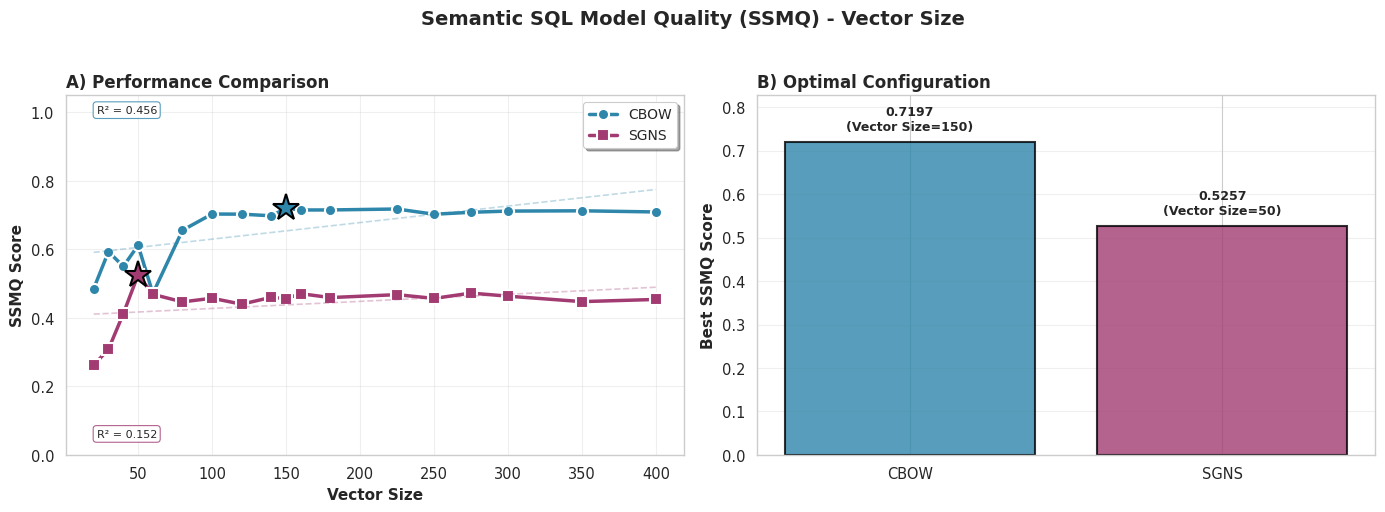

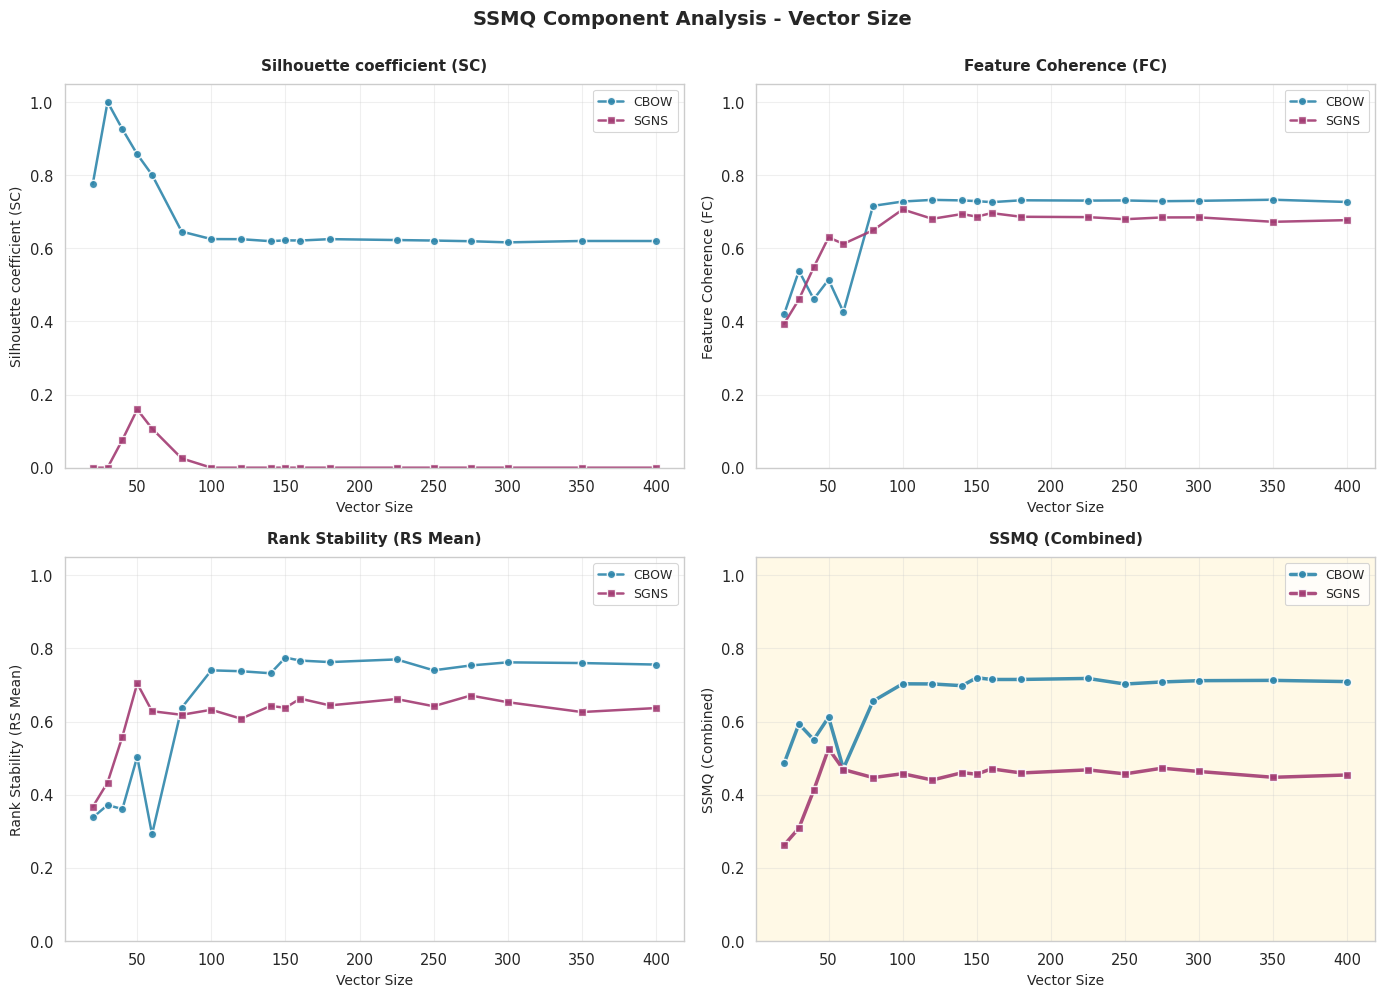


NUMERICAL RESULTS TABLE - VECTOR

Vector Size  | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
20           | 0.7757    0.4196    0.3376    0.4854    | 0.0000    0.3937    0.3666    0.2620   
30           | 1.0000    0.5385    0.3715    0.5934    | 0.0000    0.4602    0.4331    0.3086   
40           | 0.9257    0.4608    0.3605    0.5501    | 0.0761    0.5481    0.5588    0.4118   
50           | 0.8571    0.5141    0.5036    0.6118    | 0.1592    0.6298    0.7040    0.5257   
60           | 0.8009    0.4260    0.2916    0.4713    | 0.1071    0.6120    0.6282    0.4686   
80           | 0.6457    0.7160    0.6375    0.6557    | 0.0255    0.6492    0.6183    0.4466   
100          | 0.6252    0.7278    0.7399    0.7031    | 0.0000    0.7062    0.6321   

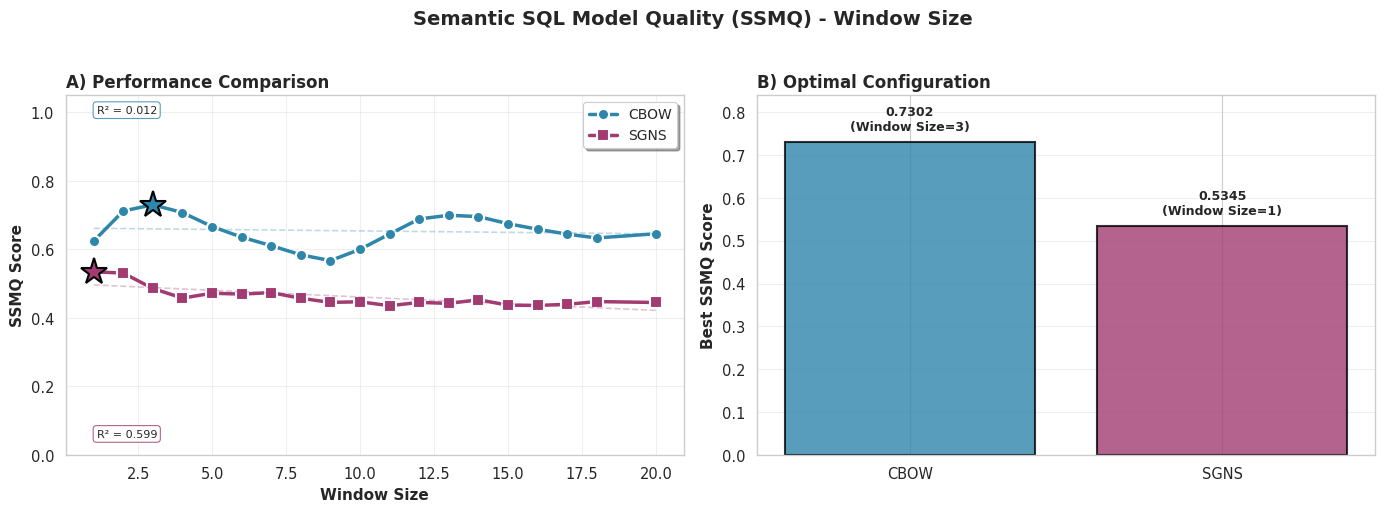

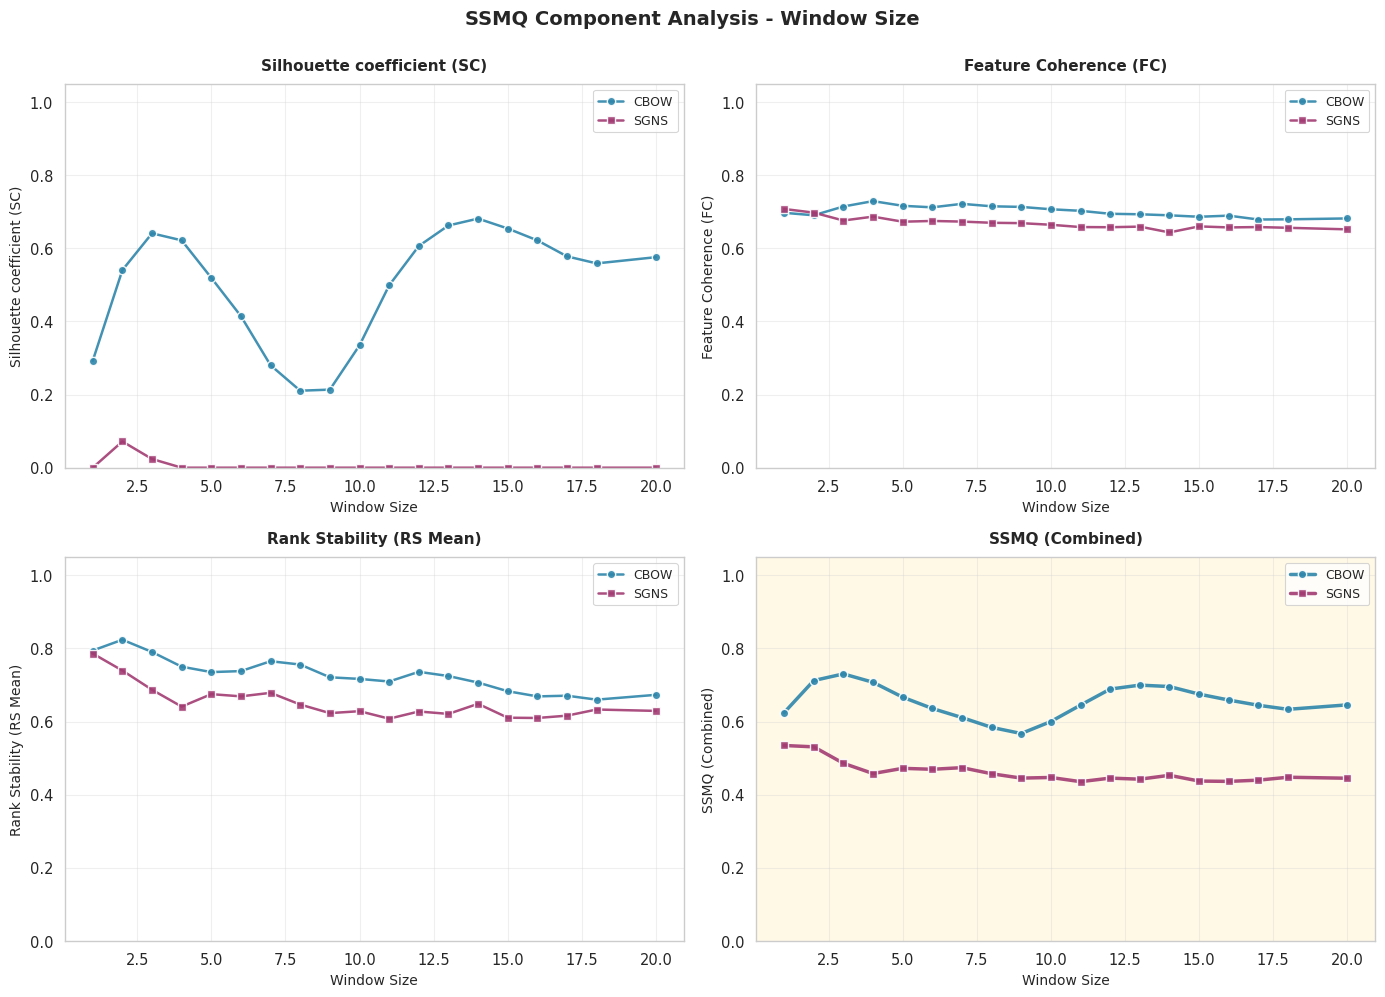


NUMERICAL RESULTS TABLE - WINDOWSIZE

Window Size  | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
1            | 0.2924    0.6971    0.7941    0.6242    | 0.0000    0.7075    0.7859    0.5345   
2            | 0.5404    0.6902    0.8236    0.7120    | 0.0718    0.6975    0.7393    0.5307   
3            | 0.6409    0.7143    0.7901    0.7302    | 0.0238    0.6760    0.6868    0.4857   
4            | 0.6217    0.7290    0.7499    0.7073    | 0.0000    0.6866    0.6408    0.4577   
5            | 0.5192    0.7162    0.7351    0.6665    | 0.0000    0.6727    0.6748    0.4719   
6            | 0.4143    0.7120    0.7379    0.6356    | 0.0000    0.6747    0.6688    0.4693   
7            | 0.2801    0.7216    0.7649    0.6108    | 0.0000    0.6730    0.678

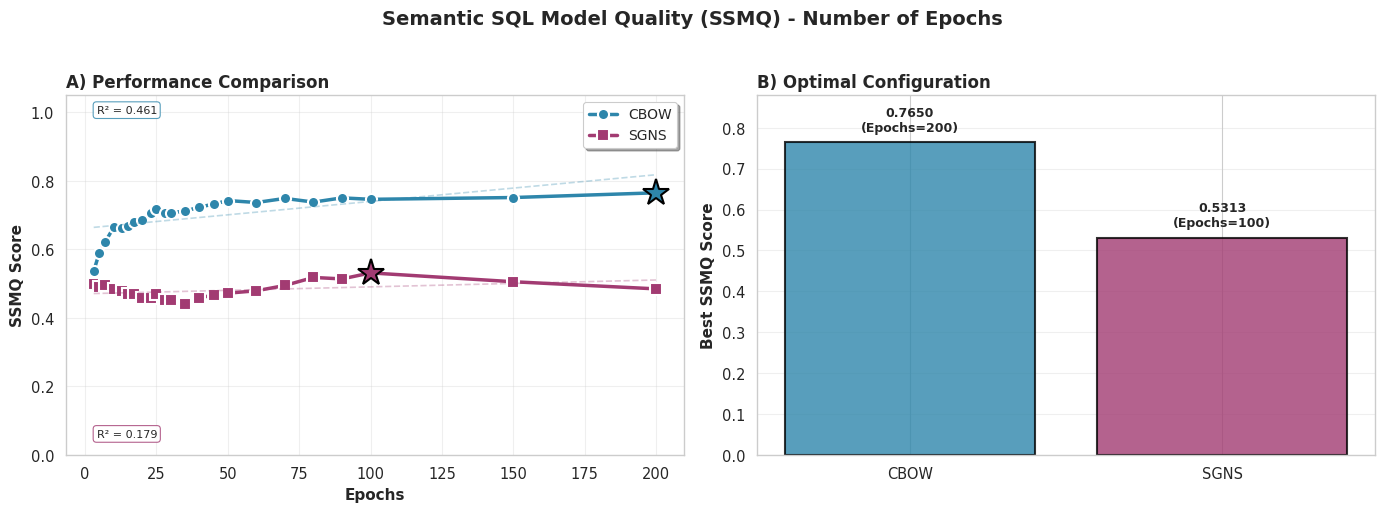

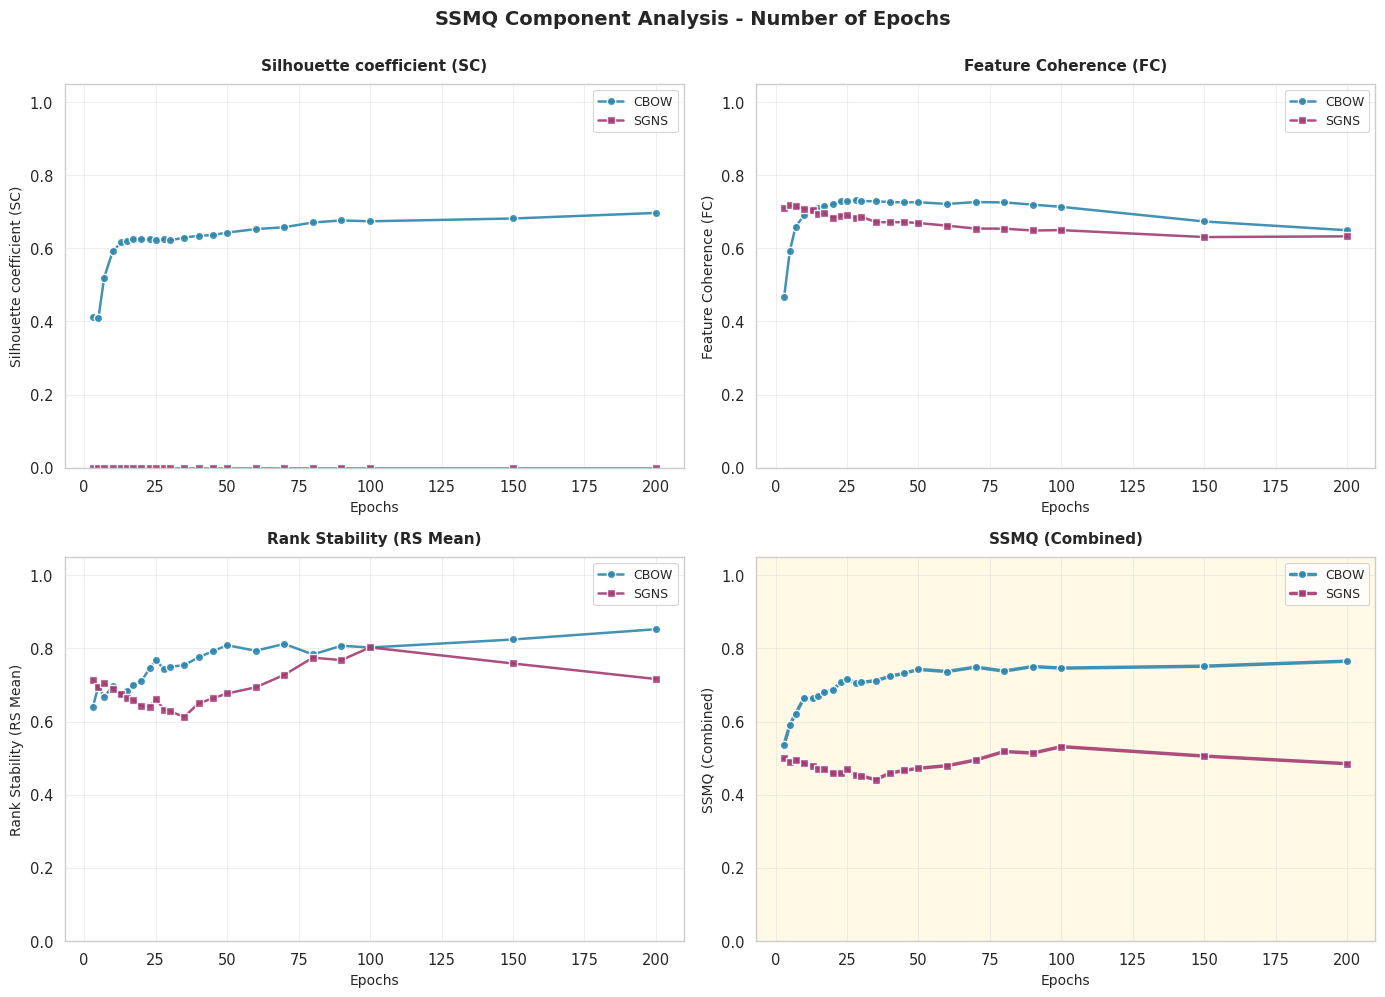


NUMERICAL RESULTS TABLE - EPOCH

Epochs       | CBOW                                     | SGNS                                    
             | SC        FC        RS        SSMQ      | SC        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
3            | 0.4131    0.4667    0.6386    0.5366    | 0.0000    0.7099    0.7148    0.4994   
5            | 0.4100    0.5924    0.6979    0.5904    | 0.0000    0.7175    0.6935    0.4903   
7            | 0.5200    0.6585    0.6669    0.6212    | 0.0000    0.7150    0.7047    0.4953   
10           | 0.5922    0.6907    0.6971    0.6644    | 0.0000    0.7079    0.6880    0.4856   
13           | 0.6162    0.7043    0.6750    0.6632    | 0.0000    0.7055    0.6753    0.4788   
15           | 0.6208    0.7088    0.6826    0.6693    | 0.0000    0.6942    0.6639    0.4708   
17           | 0.6246    0.7153    0.6990    0.6800    | 0.0000    0.6964    0.6596    

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress
from scipy import interpolate

# Wissenschaftliches Farbschema - UNVERÄNDERT
COLORS = {
    'CBOW': '#2E86AB',      # Professionelles Blau
    'SGNS': '#A23B72',      # Kontrastierendes Magenta
    'SSMQ': '#F18F01',      # Orange für Wichtigkeit
    'ND': '#6A994E',        # Grün
    'FC': '#BC4B51',        # Rot
    'RS': '#8B8C89'         # Grau
}

# Linienstärken nach Wichtigkeit
LINEWIDTHS = {
    'primary': 2.5,         # SSMQ
    'secondary': 1.8,       # ND, FC, RS_mean
    'tertiary': 1.0         # Hintergrund-Komponenten
}

# Seaborn Style Setup
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Daten nach Kategorien strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        data_by_category[category] = {
            'CBOW': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            },
            'SGNS': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            }
        }
    
    # X-Wert und Label bestimmen
    category_mapping = {
        'sentence': ('Satzlänge', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window', 'Window Size'),
        'epoch': ('Epochs', 'Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling'),
        'sample': ('Sample', 'Sample'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Alpha')
    }
    
    if category in category_mapping:
        param_key, x_label = category_mapping[category]
        x_value = result['params'][param_key]
    else:
        x_value = None
        x_label = 'Parameter'
        print(f"Unknown category: {category}")
    
    # Metriken extrahieren
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    metrics_dict = {
        'nd': nd_value,
        'rs_mean': float(result['rs_mean']) if 'rs_mean' in result else None,
        'rs_5': float(result['rs_5']) if 'rs_5' in result else None,
        'rs_10': float(result['rs_10']) if 'rs_10' in result else None,
        'rs_20': float(result['rs_20']) if 'rs_20' in result else None,
        'fc': float(result['fc']) if 'fc' in result else None,
        'ssmq': float(result['ssmq']) if 'ssmq' in result else None
    }
    
    if x_value is not None:
        for metric_name, metric_value in metrics_dict.items():
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value


def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.2)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


def plot_ssmq_main_result(category, category_data, x_label, title_category):
    """
    FIGURE 1: SSMQ Hauptergebnis (Das wichtigste Ergebnis)
    Panel A: Line Plot mit Trends
    Panel B: Best Performance Bar Chart
    """
    cbow_ssmq_data = category_data['CBOW']['ssmq']
    sgns_ssmq_data = category_data['SGNS']['ssmq']
    
    if not cbow_ssmq_data and not sgns_ssmq_data:
        print(f"No SSMQ data for {category}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Semantic SQL Model Quality (SSMQ) - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Line Plot mit Trends - UNVERÄNDERT (schon richtig)
    if cbow_ssmq_data:
        x_cbow = sorted(cbow_ssmq_data.keys())
        y_cbow = [cbow_ssmq_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='CBOW', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_cbow, y_cbow, ax1, COLORS['CBOW'], 'top')
        
        # Markiere Maximum
        max_idx = np.argmax(y_cbow)
        ax1.plot(x_cbow[max_idx], y_cbow[max_idx], '*', 
                color=COLORS['CBOW'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    if sgns_ssmq_data:
        x_sgns = sorted(sgns_ssmq_data.keys())
        y_sgns = [sgns_ssmq_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='SGNS', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_sgns, y_sgns, ax1, COLORS['SGNS'], 'bottom')
        
        # Markiere Maximum
        max_idx = np.argmax(y_sgns)
        ax1.plot(x_sgns[max_idx], y_sgns[max_idx], '*', 
                color=COLORS['SGNS'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('SSMQ Score', fontsize=11, fontweight='bold')
    ax1.set_title('A) Performance Comparison', fontsize=12, loc='left', fontweight='bold')
    ax1.legend(fontsize=10, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Best Performance Comparison
    if cbow_ssmq_data and sgns_ssmq_data:
        max_cbow = max(cbow_ssmq_data.values())
        max_sgns = max(sgns_ssmq_data.values())
        max_cbow_param = max(cbow_ssmq_data, key=cbow_ssmq_data.get)
        max_sgns_param = max(sgns_ssmq_data, key=sgns_ssmq_data.get)
        
        algorithms = ['CBOW', 'SGNS']
        scores = [max_cbow, max_sgns]
        params = [max_cbow_param, max_sgns_param]
        colors_list = [COLORS['CBOW'], COLORS['SGNS']]
        
        bars = ax2.bar(algorithms, scores, color=colors_list, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
        
        # Werte auf Balken
        for bar, score, param in zip(bars, scores, params):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}\n({x_label}={param})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Best SSMQ Score', fontsize=11, fontweight='bold')
        ax2.set_title('B) Optimal Configuration', fontsize=12, loc='left', fontweight='bold')
        ax2.set_ylim([0, max(scores) * 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Differenz anzeigen
        diff = abs(max_cbow - max_sgns)
        winner = 'CBOW' if max_cbow > max_sgns else 'SGNS'
        #ax2.text(0.5, 0.95, f'Δ = {diff:.4f}\nWinner: {winner}',
        #        transform=ax2.transAxes, ha='center', va='top',
        #        fontsize=10, fontweight='bold',
        #        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    return fig
    
    # Numerische Zusammenfassung
    print(f"\n{'='*80}")
    print(f"SSMQ SUMMARY - {title_category.upper()}")
    print(f"{'='*80}")
    if cbow_ssmq_data:
        print(f"CBOW Best: {max(cbow_ssmq_data.values()):.4f} at {x_label}={max(cbow_ssmq_data, key=cbow_ssmq_data.get)}")
    if sgns_ssmq_data:
        print(f"SGNS Best: {max(sgns_ssmq_data.values()):.4f} at {x_label}={max(sgns_ssmq_data, key=sgns_ssmq_data.get)}")
    print(f"{'='*80}\n")


def plot_component_analysis(category, category_data, x_label, title_category):
    """
    FIGURE 2: Komponenten-Analyse
    Zeigt wie sich SSMQ aus ND, FC und RS zusammensetzt
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'SSMQ Component Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    metrics_config = [
        ('nd', 'Silhouette coefficient (SC)', COLORS['ND'], axes[0, 0]),
        ('fc', 'Feature Coherence (FC)', COLORS['FC'], axes[0, 1]),
        ('rs_mean', 'Rank Stability (RS Mean)', COLORS['RS'], axes[1, 0]),
        ('ssmq', 'SSMQ (Combined)', COLORS['SSMQ'], axes[1, 1])
    ]
    
    for metric_key, metric_title, metric_color, ax in metrics_config:
        cbow_data = category_data['CBOW'][metric_key]
        sgns_data = category_data['SGNS'][metric_key]
        
        has_data = False
        
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            
            # CBOW: Immer professionelles Blau für alle Metriken
            cbow_color = COLORS['CBOW']  # Jetzt immer CBOW-Blau
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_cbow, y_cbow, '-o', color=cbow_color, 
                   linewidth=linewidth, markersize=6, label='CBOW',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            
            # SGNS: Immer kontrastierendes Magenta für alle Metriken
            sgns_color = COLORS['SGNS']  # Jetzt immer SGNS-Magenta
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_sgns, y_sgns, '-s', color=sgns_color, 
                   linewidth=linewidth, markersize=6, label='SGNS',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(metric_title, fontsize=10)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
            ax.legend(fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            # Für SSMQ: Hervorhebung
            if metric_key == 'ssmq':
                ax.set_facecolor('#FFF9E6')  # Leichter gelber Hintergrund
        else:
            ax.text(0.5, 0.5, f'No {metric_key.upper()} data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    
    plt.tight_layout()
    return fig


def plot_rank_stability_details(category, category_data, x_label, title_category):
    """
    OPTIONAL FIGURE 3: Detaillierte Rank Stability Analyse
    Nur wenn RS-Komponenten relevant sind
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Rank Stability Details - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    rs_components = ['rs_5', 'rs_10', 'rs_20']
    rs_labels = ['RS @5', 'RS @10', 'RS @20']
    rs_styles = [':', '--', '-.']
    
    # CBOW RS Components - Jetzt in hellen Blautönen
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['CBOW'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax1.plot(x, y, style, color='#87CEEB', alpha=0.7,  # Heller Blauton für CBOW
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # CBOW RS Mean (prominent) - Jetzt in voller CBOW-Farbe
    cbow_mean_data = category_data['CBOW']['rs_mean']
    if cbow_mean_data:
        x = sorted(cbow_mean_data.keys())
        y = [cbow_mean_data[xi] for xi in x]
        ax1.plot(x, y, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax1.set_title('CBOW - Rank Stability', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, frameon=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # SGNS RS Components - Jetzt in hellen Magentatönen
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['SGNS'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax2.plot(x, y, style, color='#FFB6C1', alpha=0.7,  # Heller Magentaton für SGNS
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # SGNS RS Mean (prominent) - Jetzt in voller SGNS-Farbe
    sgns_mean_data = category_data['SGNS']['rs_mean']
    if sgns_mean_data:
        x = sorted(sgns_mean_data.keys())
        y = [sgns_mean_data[xi] for xi in x]
        ax2.plot(x, y, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax2.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax2.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax2.set_title('SGNS - Rank Stability', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, frameon=True)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    return fig


def create_summary_table(category, category_data, x_label):
    """
    Erstellt formatierte Tabelle für wissenschaftliche Arbeit
    """
    print(f"\n{'='*100}")
    print(f"NUMERICAL RESULTS TABLE - {category.upper()}")
    print(f"{'='*100}")
    
    # Sammle alle x-Werte
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['nd', 'fc', 'rs_mean', 'ssmq']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if not sorted_x:
        print("No data available")
        return
    
    # Header
    print(f"\n{x_label:<12} | {'CBOW':<40} | {'SGNS':<40}")
    print(f"{'':<12} | {'SC':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9} | {'SC':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9}")
    print("-" * 100)
    
    # Datenzeilen
    for x in sorted_x:
        cbow_nd = category_data['CBOW']['nd'].get(x, None)
        cbow_fc = category_data['CBOW']['fc'].get(x, None)
        cbow_rs = category_data['CBOW']['rs_mean'].get(x, None)
        cbow_ssmq = category_data['CBOW']['ssmq'].get(x, None)
        
        sgns_nd = category_data['SGNS']['nd'].get(x, None)
        sgns_fc = category_data['SGNS']['fc'].get(x, None)
        sgns_rs = category_data['SGNS']['rs_mean'].get(x, None)
        sgns_ssmq = category_data['SGNS']['ssmq'].get(x, None)
        
        def fmt(val):
            return f"{val:.4f}" if val is not None else "N/A"
        
        print(f"{str(x):<12} | {fmt(cbow_nd):<9} {fmt(cbow_fc):<9} {fmt(cbow_rs):<9} {fmt(cbow_ssmq):<9} | "
              f"{fmt(sgns_nd):<9} {fmt(sgns_fc):<9} {fmt(sgns_rs):<9} {fmt(sgns_ssmq):<9}")
    
    print(f"{'='*100}\n")


# Hauptschleife: Erzeuge Plots für jede Kategorie
print("\n" + "="*100)
print("WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION")
print("="*100 + "\n")

for category, category_data in data_by_category.items():
    # Label-Mapping
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # FIGURE 1: Hauptergebnis SSMQ
    fig1 = plot_ssmq_main_result(category, category_data, x_label, title_category)
    render_figure(fig1, f"SSMQ_main_{category}")
    
    # FIGURE 2: Komponenten-Analyse
    fig2 = plot_component_analysis(category, category_data, x_label, title_category)
    render_figure(fig2, f"SSMQ_components_{category}")
    
    # OPTIONAL FIGURE 3: RS Details (nur wenn interessant)
    # plot_rank_stability_details(category, category_data, x_label, title_category)
    
    # TABLE: Numerische Ergebnisse
    create_summary_table(category, category_data, x_label)


print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)


KEY-VALUE COHERENCE (KVC) ANALYSIS - SCIENTIFIC VISUALIZATION


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



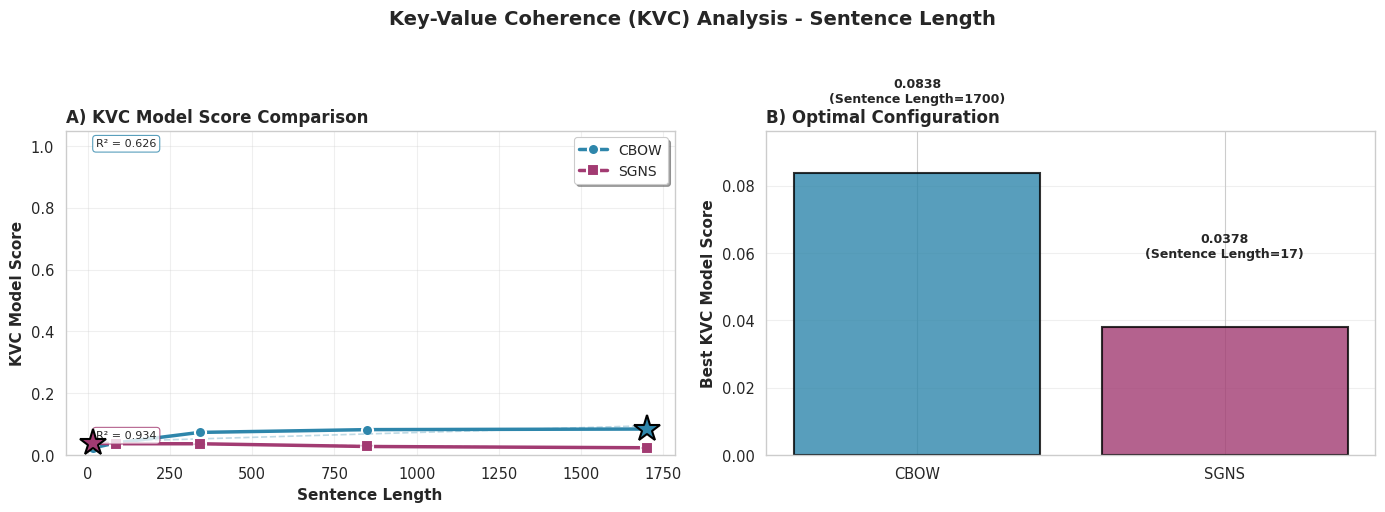

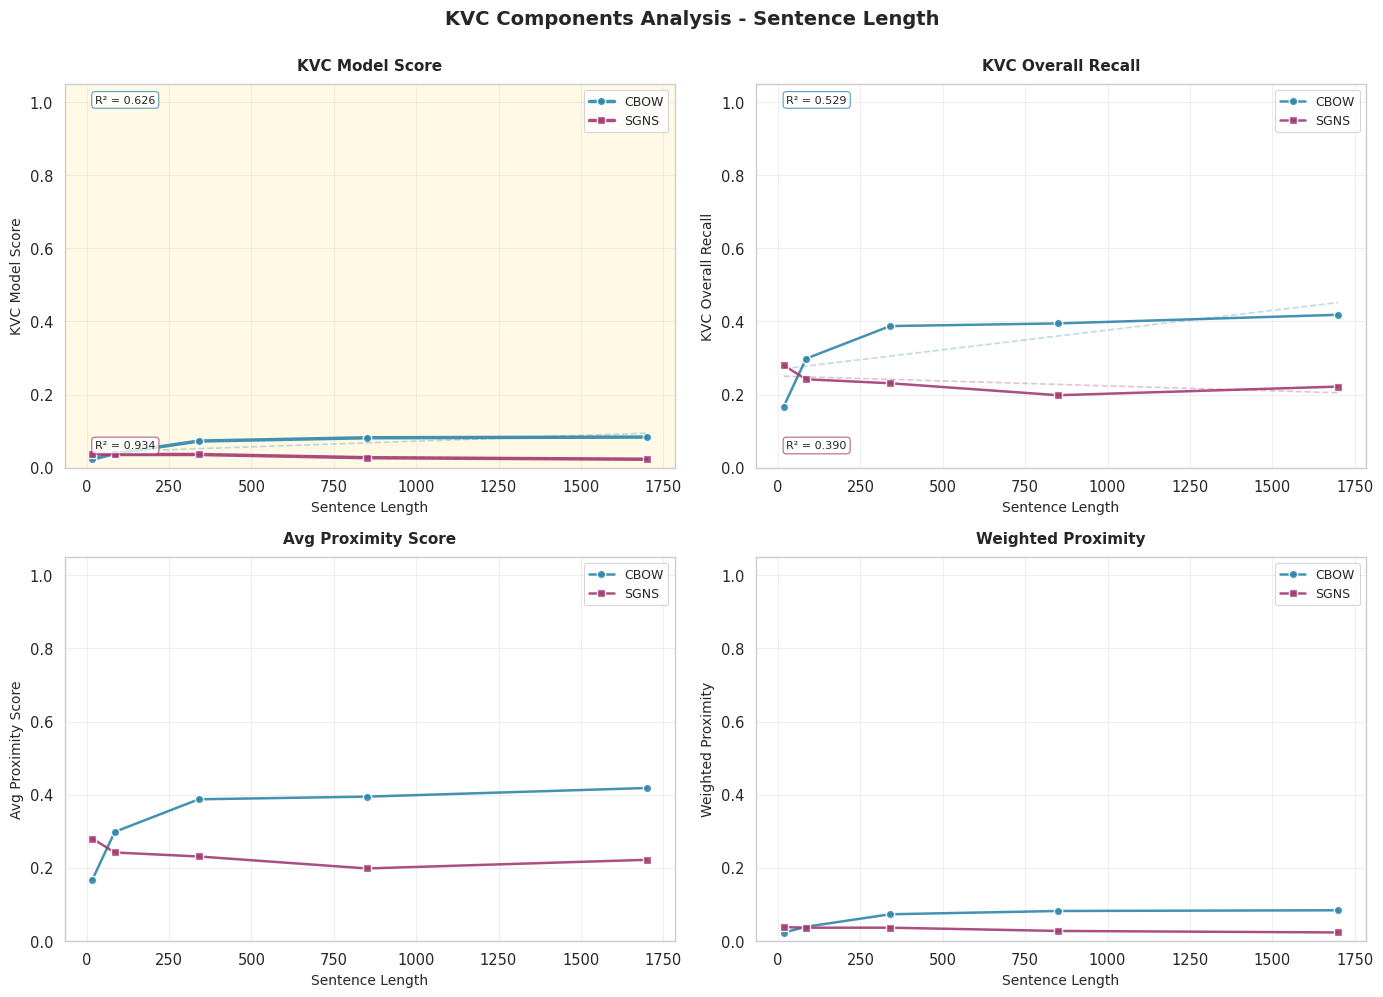

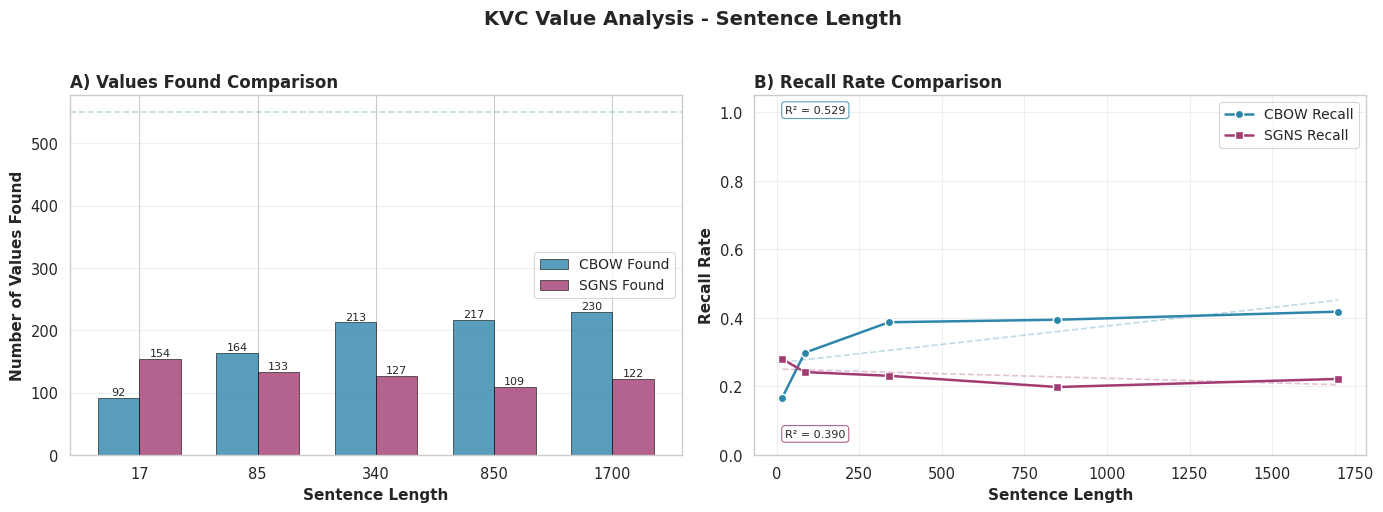


KVC NUMERICAL RESULTS - SENTENCE LENGTH

Sentence Length | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
17           | 0.0227     0.1673     0.1673     0.0227     | 0.0378     0.2800     0.2800     0.0378    
85           | 0.0388     0.2982     0.2982     0.0388     | 0.0362     0.2418     0.2418     0.0362    
340          | 0.0729     0.3873     0.3873     0.0729     | 0.0361     0.2309     0.2309     0.0361    
850          | 0.0818     0.3945     0.3945     0.0818     | 0.0273     0.1982     0.1982     0.0273    
1700         | 0.0838     0.4182     0.4182     0.0838     | 0.0232     0.2218     0.2218     0.0232    

KVC VALUE

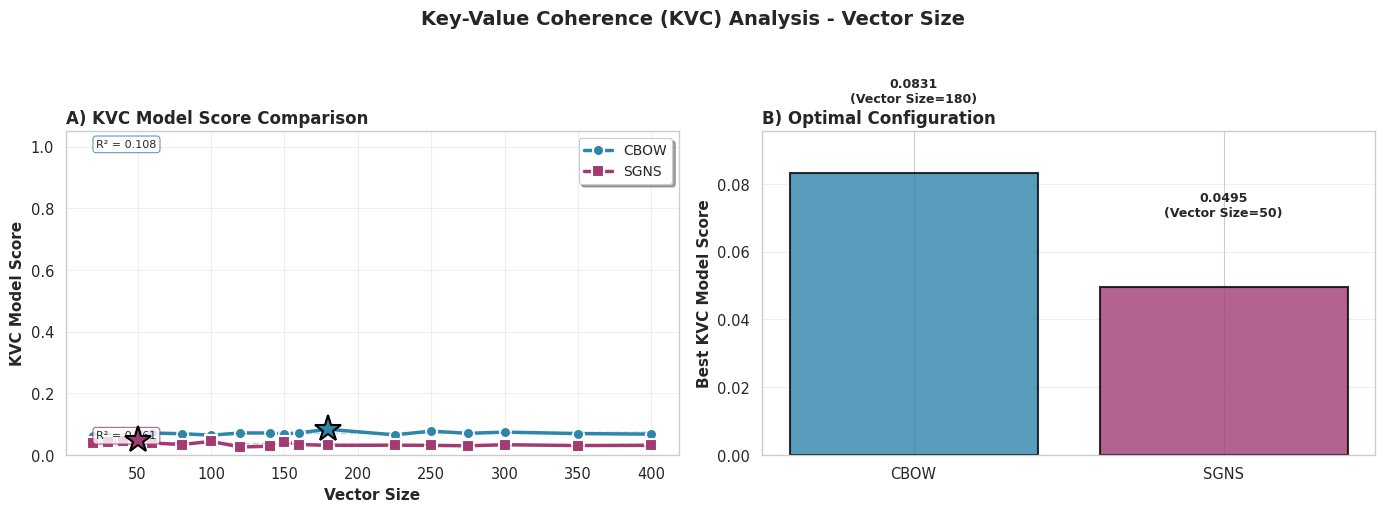

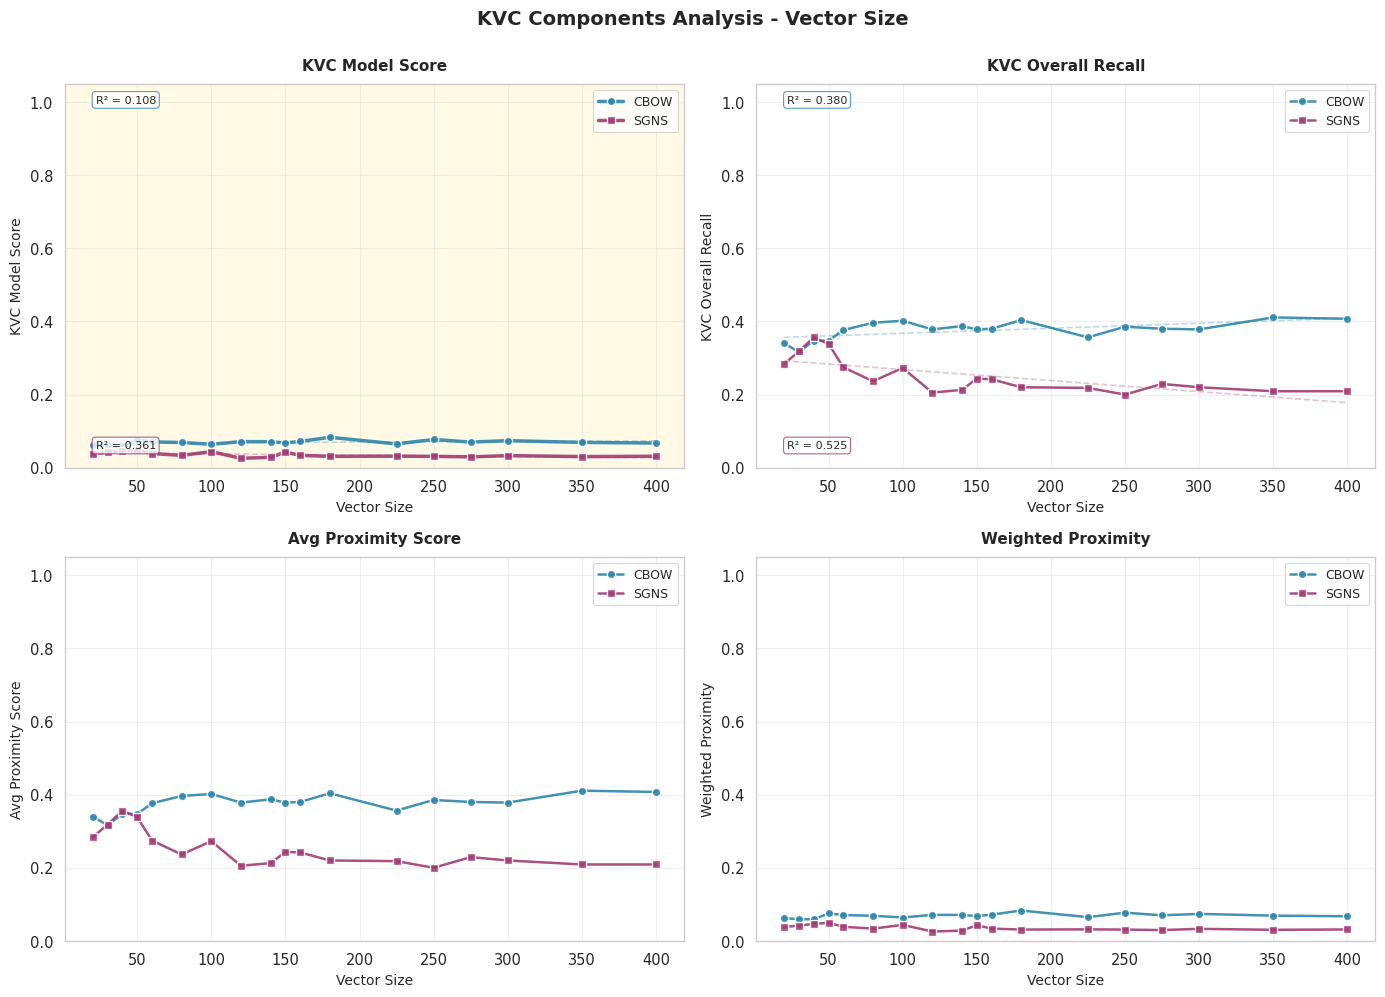

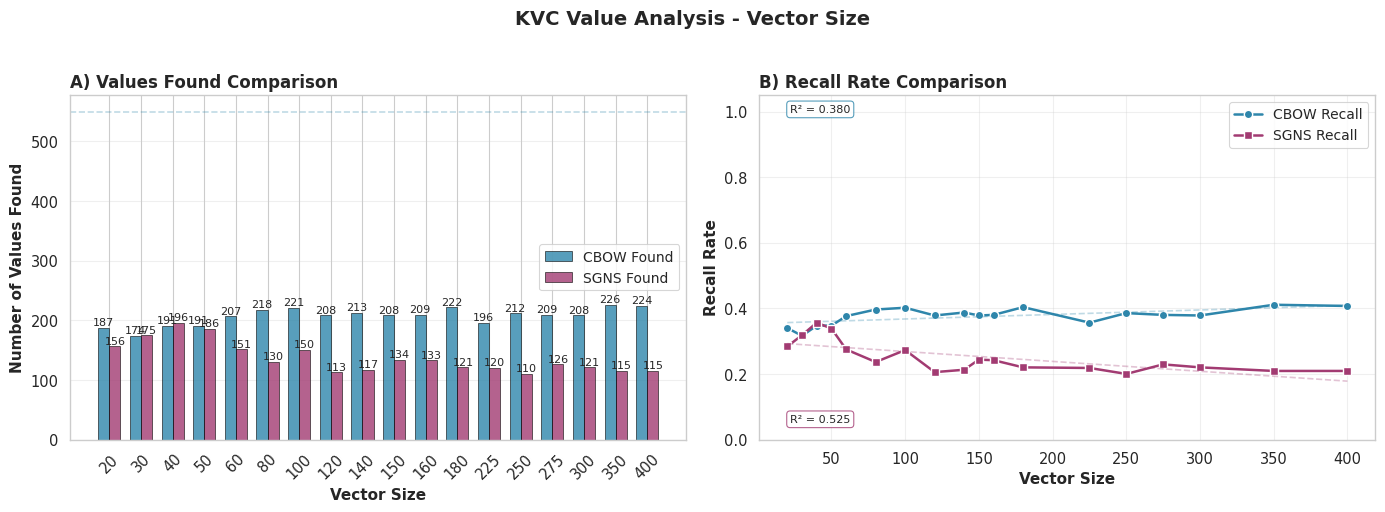


KVC NUMERICAL RESULTS - VECTOR SIZE

Vector Size  | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
20           | 0.0624     0.3400     0.3400     0.0624     | 0.0379     0.2836     0.2836     0.0379    
30           | 0.0593     0.3164     0.3164     0.0593     | 0.0419     0.3182     0.3182     0.0419    
40           | 0.0590     0.3473     0.3473     0.0590     | 0.0464     0.3564     0.3564     0.0464    
50           | 0.0753     0.3473     0.3473     0.0753     | 0.0495     0.3382     0.3382     0.0495    
60           | 0.0706     0.3764     0.3764     0.0706     | 0.0387     0.2745     0.2745     0.0387    
80           | 0.

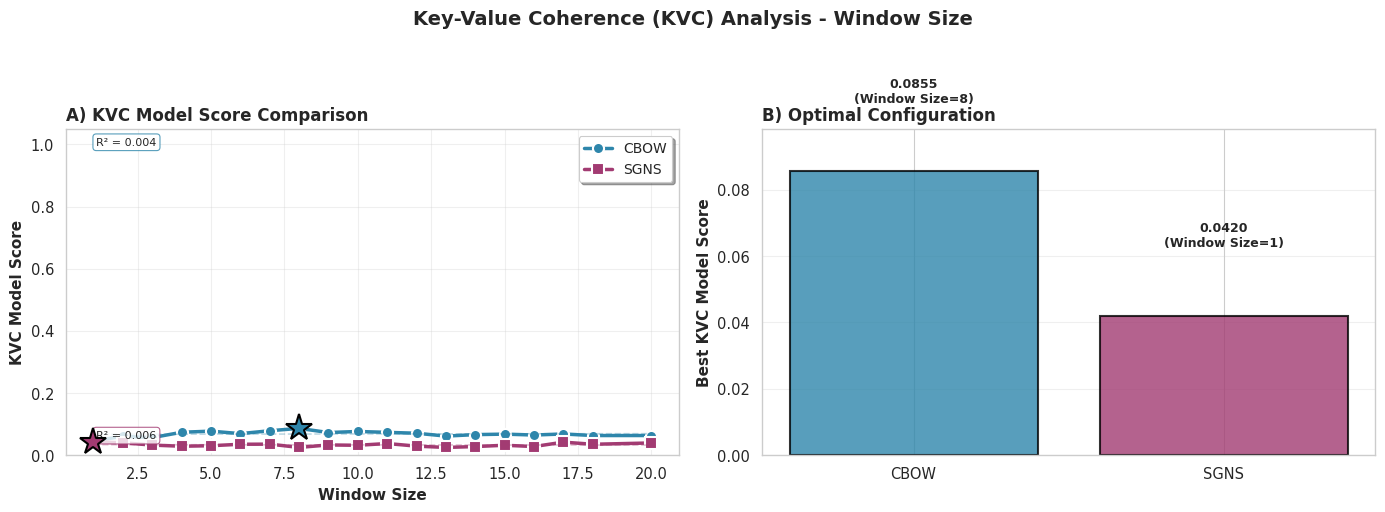

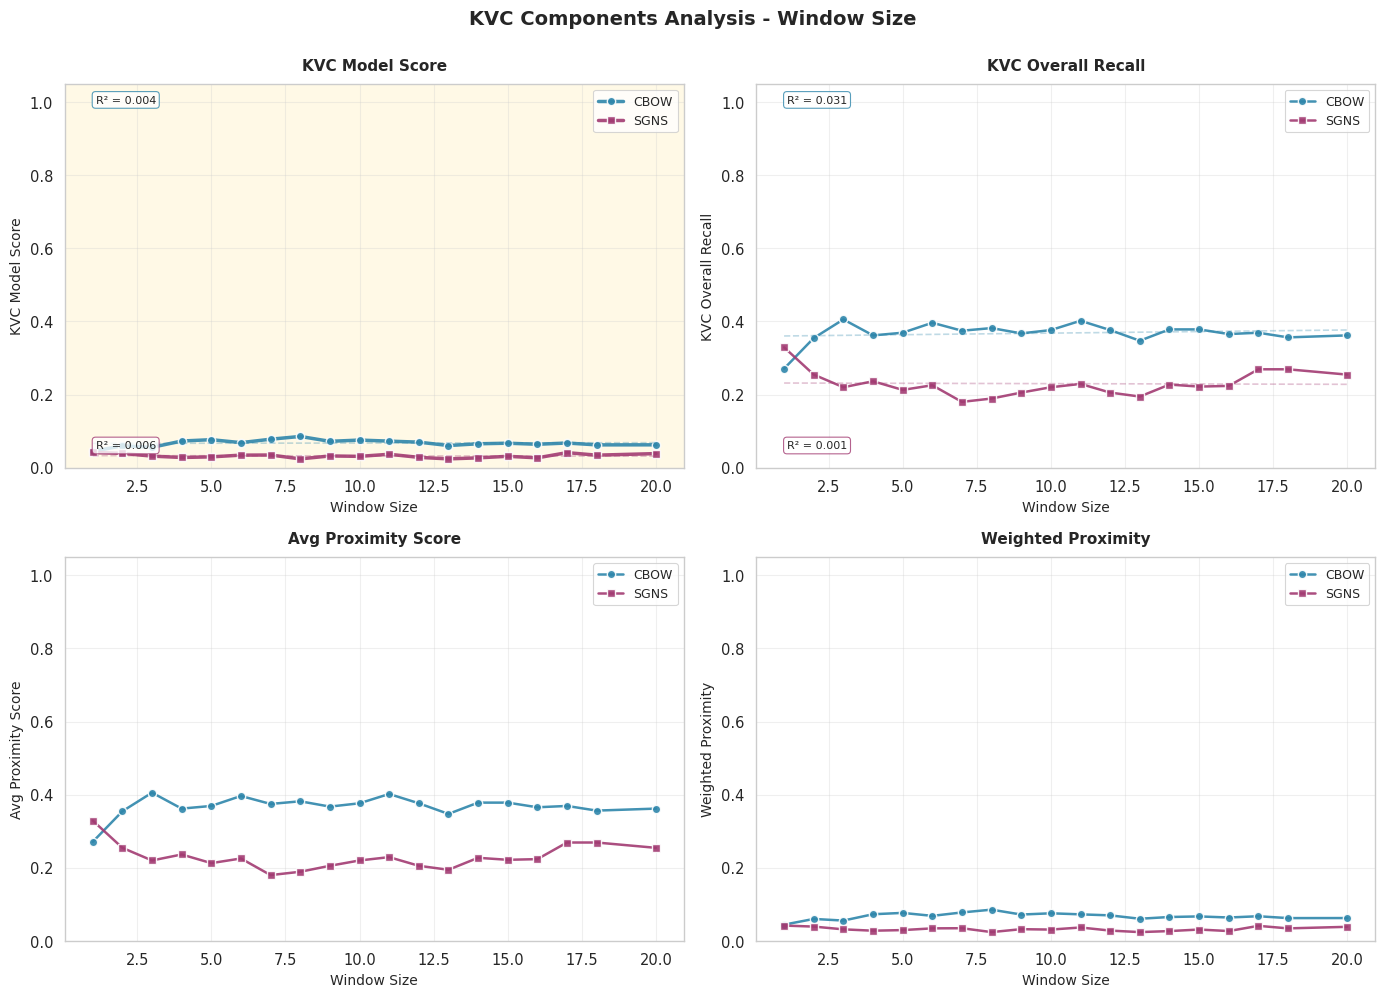

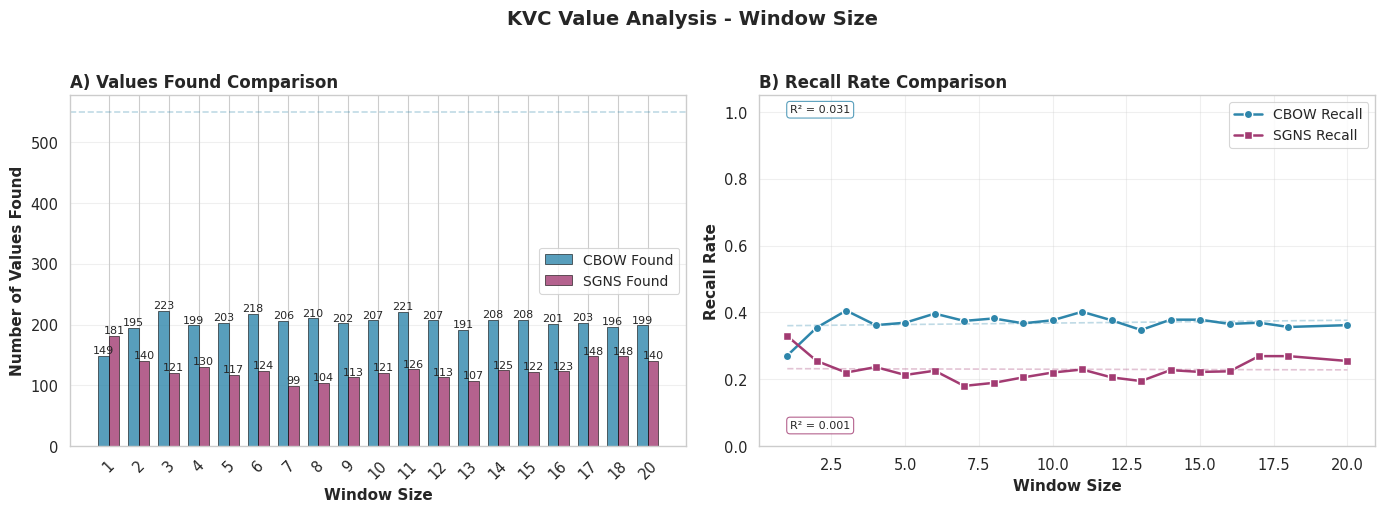


KVC NUMERICAL RESULTS - WINDOW SIZE

Window Size  | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
1            | 0.0445     0.2709     0.2709     0.0445     | 0.0420     0.3291     0.3291     0.0420    
2            | 0.0601     0.3545     0.3545     0.0601     | 0.0392     0.2545     0.2545     0.0392    
3            | 0.0556     0.4055     0.4055     0.0556     | 0.0316     0.2200     0.2200     0.0316    
4            | 0.0729     0.3618     0.3618     0.0729     | 0.0279     0.2364     0.2364     0.0279    
5            | 0.0766     0.3691     0.3691     0.0766     | 0.0296     0.2127     0.2127     0.0296    
6            | 0.

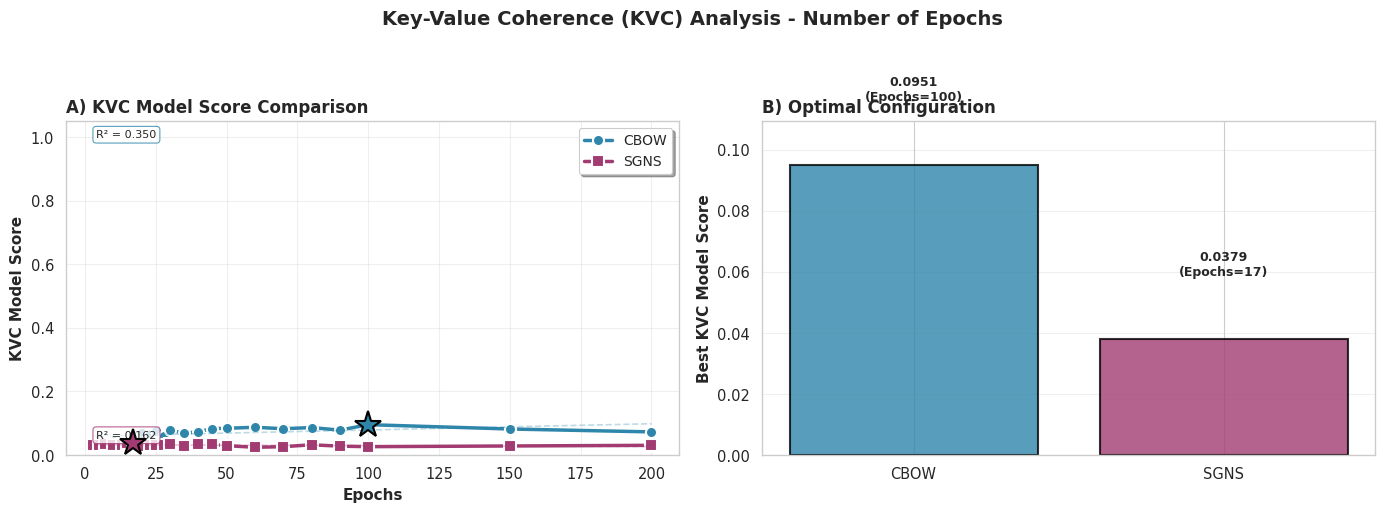

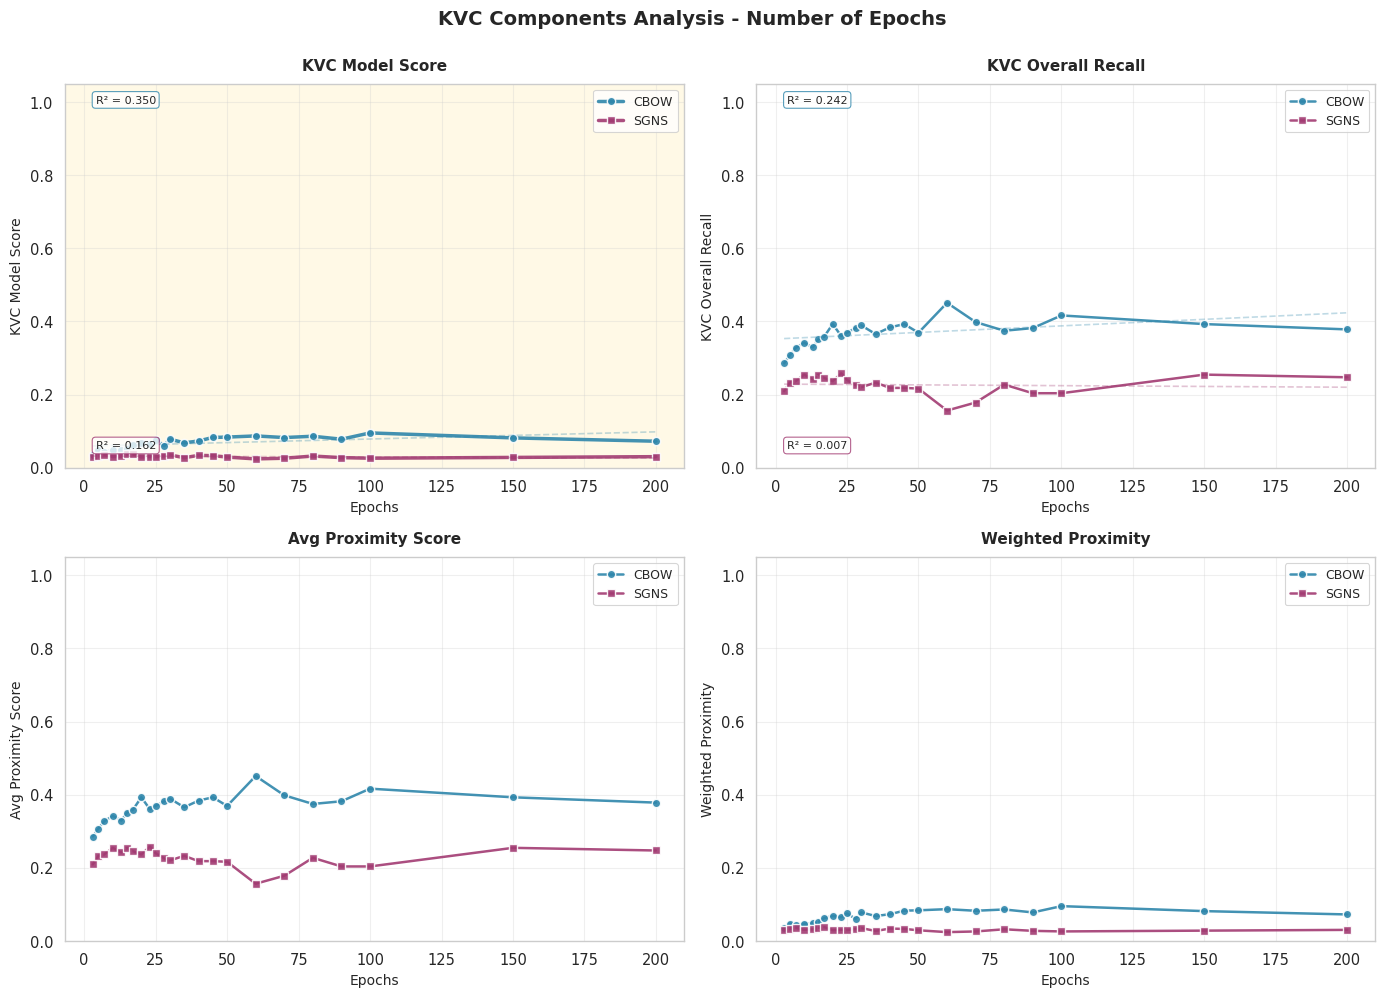

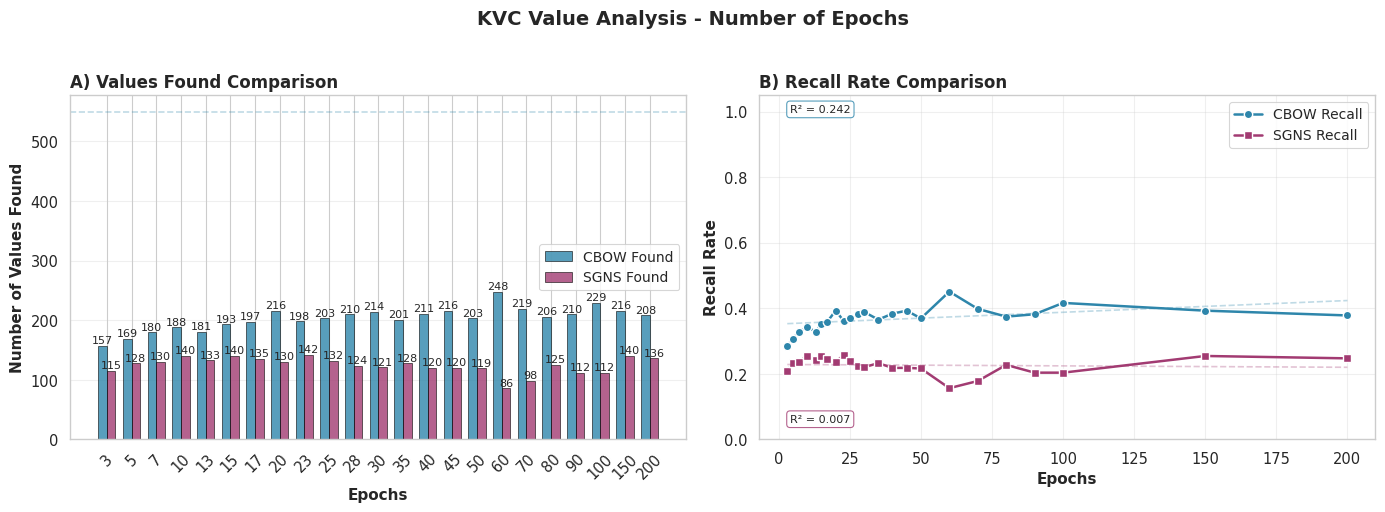


KVC NUMERICAL RESULTS - NUMBER OF EPOCHS

Epochs       | CBOW                                          | SGNS                                         
             | Model      Recall     Avg        Wtd        | Model      Recall     Avg        Wtd       
             | Score      Rate       Prox       Prox       | Score      Rate       Prox       Prox      
----------------------------------------------------------------------------------------------------
3            | 0.0358     0.2855     0.2855     0.0358     | 0.0297     0.2091     0.2091     0.0297    
5            | 0.0472     0.3073     0.3073     0.0472     | 0.0319     0.2327     0.2327     0.0319    
7            | 0.0437     0.3273     0.3273     0.0437     | 0.0357     0.2364     0.2364     0.0357    
10           | 0.0470     0.3418     0.3418     0.0470     | 0.0303     0.2545     0.2545     0.0303    
13           | 0.0492     0.3291     0.3291     0.0492     | 0.0315     0.2418     0.2418     0.0315    
15          

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress

# Wissenschaftliches Farbschema (konsistent mit script_2)
COLORS = {
    'CBOW': '#2E86AB',      # Professionelles Blau
    'SGNS': '#A23B72',      # Kontrastierendes Magenta
    'KVC_MODEL': '#F18F01', # Orange für Model Score
    'KVC_RECALL': '#6A994E', # Grün für Recall
    'KVC_AVG': '#8B8C89',   # Grau für Avg Proximity
    'KVC_WEIGHTED': '#BC4B51' # Rot für Weighted Proximity
}

# Linienstärken nach Wichtigkeit
LINEWIDTHS = {
    'primary': 2.5,         # KVC Model Score
    'secondary': 1.8,       # KVC Recall
    'tertiary': 1.0         # Andere KVC Metriken
}

# Seaborn Style Setup (wie in script_2)
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# ============================================================
# DATENVORBEREITUNG FÜR KVC-METRIKEN (AUS SCRIPT_1)
# ============================================================

# Daten nach Kategorien und Algorithmen strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        # Erweiterte Datenstruktur für alle Metriken inklusive KVC
        data_by_category[category] = {
            'CBOW': {
                # Hauptmetriken
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {},
                # KVC Metriken
                'kvc_model_score': {}, 'kvc_avg_proximity': {}, 'kvc_weighted_proximity': {},
                'kvc_recall': {}, 'kvc_found_values': {}, 'kvc_possible_values': {},
                'kvc_keys_evaluated': {}
            },
            'SGNS': {
                # Hauptmetriken
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {},
                # KVC Metriken
                'kvc_model_score': {}, 'kvc_avg_proximity': {}, 'kvc_weighted_proximity': {},
                'kvc_recall': {}, 'kvc_found_values': {}, 'kvc_possible_values': {},
                'kvc_keys_evaluated': {}
            }
        }
    
    # Determine which parameter is relevant for this category
    if category == 'sentence':
        x_value = result['params']['Satzlänge']
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_value = result['params']['Vector Size']
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_value = result['params']['Window']
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_value = result['params']['Epochs']
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_value = result['params']['Negative Sampling']
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_value = result['params']['Sample']
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_value = result['params']['Hierarchical Softmax']
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_value = result['params']['Alpha']
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_value = None
        x_label = 'UNKNOWN - PLEASE SET'
        title_category = category
        print(f"Unknown category: {category}")
    
    # Extract all metrics if they exist
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    # Extract other main metrics
    rs_mean_value = float(result['rs_mean']) if 'rs_mean' in result else None
    rs_5_value = float(result['rs_5']) if 'rs_5' in result else None
    rs_10_value = float(result['rs_10']) if 'rs_10' in result else None
    rs_20_value = float(result['rs_20']) if 'rs_20' in result else None
    fc_value = float(result['fc']) if 'fc' in result else None
    ssmq_value = float(result['ssmq']) if 'ssmq' in result else None
    
    # Extract KVC metrics if they exist
    kvc_model_score = None
    kvc_avg_proximity = None
    kvc_weighted_proximity = None
    kvc_recall = None
    kvc_found_values = None
    kvc_possible_values = None
    kvc_keys_evaluated = None
    
    if 'kvc' in result:
        kvc_data = result['kvc']
        kvc_model_score = float(kvc_data.get('model_score', 0))
        kvc_avg_proximity = float(kvc_data.get('avg_proximity_score', 0))
        kvc_weighted_proximity = float(kvc_data.get('avg_weighted_proximity_score', 0))
        
        # Calculate recall if not directly available
        if 'overall_recall' in kvc_data:
            kvc_recall = float(kvc_data['overall_recall'])
        elif 'total_found_values' in kvc_data and 'total_possible_values' in kvc_data:
            total_found = kvc_data['total_found_values']
            total_possible = kvc_data['total_possible_values']
            kvc_recall = total_found / total_possible if total_possible > 0 else 0
        
        kvc_found_values = kvc_data.get('total_found_values', 0)
        kvc_possible_values = kvc_data.get('total_possible_values', 0)
        kvc_keys_evaluated = kvc_data.get('keys_evaluated', 0)
    
    if x_value is not None:
        # Store all available metrics
        main_metrics = [
            ('nd', nd_value),
            ('rs_mean', rs_mean_value),
            ('rs_5', rs_5_value),
            ('rs_10', rs_10_value),
            ('rs_20', rs_20_value),
            ('fc', fc_value),
            ('ssmq', ssmq_value)
        ]
        
        kvc_metrics = [
            ('kvc_model_score', kvc_model_score),
            ('kvc_avg_proximity', kvc_avg_proximity),
            ('kvc_weighted_proximity', kvc_weighted_proximity),
            ('kvc_recall', kvc_recall),
            ('kvc_found_values', kvc_found_values),
            ('kvc_possible_values', kvc_possible_values),
            ('kvc_keys_evaluated', kvc_keys_evaluated)
        ]
        
        # Store main metrics
        for metric_name, metric_value in main_metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value
        
        # Store KVC metrics
        for metric_name, metric_value in kvc_metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value

# ============================================================
# VISUALISIERUNGSFUNKTIONEN (IM STIL VON SCRIPT_2)
# ============================================================

def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu (aus script_2)"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.2)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


def plot_kvc_main_result(category, category_data, x_label, title_category):
    """
    FIGURE 1: KVC Hauptergebnis (Analog zu SSMQ in script_2)
    Panel A: KVC Model Score mit Trends
    Panel B: Best Performance Comparison
    """
    cbow_kvc_data = category_data['CBOW']['kvc_model_score']
    sgns_kvc_data = category_data['SGNS']['kvc_model_score']
    
    if not cbow_kvc_data and not sgns_kvc_data:
        print(f"No KVC Model Score data for {category}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Key-Value Coherence (KVC) Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Line Plot mit Trends
    if cbow_kvc_data:
        x_cbow = sorted(cbow_kvc_data.keys())
        y_cbow = [cbow_kvc_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='CBOW', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_cbow, y_cbow, ax1, COLORS['CBOW'], 'top')
        
        # Markiere Maximum
        max_idx = np.argmax(y_cbow)
        ax1.plot(x_cbow[max_idx], y_cbow[max_idx], '*', 
                color=COLORS['CBOW'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    if sgns_kvc_data:
        x_sgns = sorted(sgns_kvc_data.keys())
        y_sgns = [sgns_kvc_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='SGNS', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_sgns, y_sgns, ax1, COLORS['SGNS'], 'bottom')
        
        # Markiere Maximum
        max_idx = np.argmax(y_sgns)
        ax1.plot(x_sgns[max_idx], y_sgns[max_idx], '*', 
                color=COLORS['SGNS'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('KVC Model Score', fontsize=11, fontweight='bold')
    ax1.set_title('A) KVC Model Score Comparison', fontsize=12, loc='left', fontweight='bold')
    ax1.legend(fontsize=10, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Best Performance Comparison
    if cbow_kvc_data and sgns_kvc_data:
        max_cbow = max(cbow_kvc_data.values())
        max_sgns = max(sgns_kvc_data.values())
        max_cbow_param = max(cbow_kvc_data, key=cbow_kvc_data.get)
        max_sgns_param = max(sgns_kvc_data, key=sgns_kvc_data.get)
        
        algorithms = ['CBOW', 'SGNS']
        scores = [max_cbow, max_sgns]
        params = [max_cbow_param, max_sgns_param]
        colors_list = [COLORS['CBOW'], COLORS['SGNS']]
        
        bars = ax2.bar(algorithms, scores, color=colors_list, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
        
        # Werte auf Balken
        for bar, score, param in zip(bars, scores, params):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}\n({x_label}={param})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Best KVC Model Score', fontsize=11, fontweight='bold')
        ax2.set_title('B) Optimal Configuration', fontsize=12, loc='left', fontweight='bold')
        ax2.set_ylim([0, max(scores) * 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Differenz anzeigen
        diff = abs(max_cbow - max_sgns)
        winner = 'CBOW' if max_cbow > max_sgns else 'SGNS'
        #ax2.text(0.5, 0.95, f'Δ = {diff:.4f}\nwinner: {winner}',
        #       transform=ax2.transAxes, ha='center', va='top',
        #        fontsize=10, fontweight='bold',
        #       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    return fig
    
    # Numerische Zusammenfassung
    print(f"\n{'='*80}")
    print(f"KVC MODEL SCORE SUMMARY - {title_category.upper()}")
    print(f"{'='*80}")
    if cbow_kvc_data:
        print(f"CBOW Best: {max(cbow_kvc_data.values()):.4f} at {x_label}={max(cbow_kvc_data, key=cbow_kvc_data.get)}")
    if sgns_kvc_data:
        print(f"SGNS Best: {max(sgns_kvc_data.values()):.4f} at {x_label}={max(sgns_kvc_data, key=sgns_kvc_data.get)}")
    print(f"{'='*80}\n")


def plot_kvc_component_analysis(category, category_data, x_label, title_category):
    """
    FIGURE 2: KVC Komponenten-Analyse (Analog zu SSMQ Component Analysis in script_2)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'KVC Components Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Angepasste KVC-Metriken für die Panel-Darstellung
    metrics_config = [
        ('kvc_model_score', 'KVC Model Score', COLORS['KVC_MODEL'], axes[0, 0]),
        ('kvc_recall', 'KVC Overall Recall', COLORS['KVC_RECALL'], axes[0, 1]),
        ('kvc_avg_proximity', 'Avg Proximity Score', COLORS['KVC_AVG'], axes[1, 0]),
        ('kvc_weighted_proximity', 'Weighted Proximity', COLORS['KVC_WEIGHTED'], axes[1, 1])
    ]
    
    for metric_key, metric_title, metric_color, ax in metrics_config:
        cbow_data = category_data['CBOW'][metric_key]
        sgns_data = category_data['SGNS'][metric_key]
        
        has_data = False
        
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            
            # CBOW immer in eigenem Farbton
            cbow_color = COLORS['CBOW'] if metric_key == 'kvc_model_score' else COLORS['CBOW']
            linewidth = LINEWIDTHS['primary'] if metric_key == 'kvc_model_score' else LINEWIDTHS['secondary']
            
            ax.plot(x_cbow, y_cbow, '-o', color=cbow_color, 
                   linewidth=linewidth, markersize=6, label='CBOW',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
            
            # Trendlinie für wichtige Metriken
            if metric_key in ['kvc_model_score', 'kvc_recall']:
                add_trend_analysis(x_cbow, y_cbow, ax, cbow_color, 'top')
        
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            
            # SGNS immer in eigenem Farbton
            sgns_color = COLORS['SGNS'] if metric_key == 'kvc_model_score' else COLORS['SGNS']
            linewidth = LINEWIDTHS['primary'] if metric_key == 'kvc_model_score' else LINEWIDTHS['secondary']
            
            ax.plot(x_sgns, y_sgns, '-s', color=sgns_color, 
                   linewidth=linewidth, markersize=6, label='SGNS',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
            
            # Trendlinie für wichtige Metriken
            if metric_key in ['kvc_model_score', 'kvc_recall']:
                add_trend_analysis(x_sgns, y_sgns, ax, sgns_color, 'bottom')
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(metric_title, fontsize=10)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
            ax.legend(fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            # Für KVC Model Score: Hervorhebung
            if metric_key == 'kvc_model_score':
                ax.set_facecolor('#FFF9E6')  # Leichter gelber Hintergrund (wie in script_2)
        else:
            ax.text(0.5, 0.5, f'No {metric_key} data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    
    plt.tight_layout()
    return fig


def plot_kvc_values_comparison(category, category_data, x_label, title_category):
    """
    FIGURE 3: KVC Values Vergleich (Verbesserte Version)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'KVC Value Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Found vs Possible Values (Grouped Bar Chart)
    x_values = sorted(set(list(category_data['CBOW']['kvc_found_values'].keys()) + 
                          list(category_data['SGNS']['kvc_found_values'].keys())))
    
    if x_values:
        # Get data for bar chart
        cbow_found = [category_data['CBOW']['kvc_found_values'].get(x, 0) for x in x_values]
        sgns_found = [category_data['SGNS']['kvc_found_values'].get(x, 0) for x in x_values]
        cbow_possible = [category_data['CBOW']['kvc_possible_values'].get(x, 0) for x in x_values]
        sgns_possible = [category_data['SGNS']['kvc_possible_values'].get(x, 0) for x in x_values]
        
        x_pos = np.arange(len(x_values))
        width = 0.35
        
        # Create grouped bar chart
        bars1 = ax1.bar(x_pos - width/2, cbow_found, width, 
                       label='CBOW Found', color=COLORS['CBOW'], alpha=0.8,
                       edgecolor='black', linewidth=0.5)
        bars2 = ax1.bar(x_pos + width/2, sgns_found, width, 
                       label='SGNS Found', color=COLORS['SGNS'], alpha=0.8,
                       edgecolor='black', linewidth=0.5)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{int(height)}', ha='center', va='bottom', fontsize=8)
        
        ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
        ax1.set_ylabel('Number of Values Found', fontsize=11, fontweight='bold')
        ax1.set_title('A) Values Found Comparison', fontsize=12, loc='left', fontweight='bold')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(x_values, rotation=45 if len(x_values) > 5 else 0)
        ax1.legend(fontsize=10, frameon=True)
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Add possible values as horizontal lines
        if any(cbow_possible):
            max_possible = max(cbow_possible)
            ax1.axhline(y=max_possible, color=COLORS['CBOW'], linestyle='--', 
                       alpha=0.3, label='Max Possible (CBOW)')
    
    else:
        ax1.text(0.5, 0.5, 'No KVC Values data', 
                ha='center', va='center', transform=ax1.transAxes, fontsize=12)
        ax1.set_title('A) Values Found Comparison', fontsize=12, loc='left', fontweight='bold')
    
    # Panel B: Recall Rate Comparison (Line Plot)
    cbow_recall = category_data['CBOW']['kvc_recall']
    sgns_recall = category_data['SGNS']['kvc_recall']
    
    if cbow_recall or sgns_recall:
        if cbow_recall:
            x_cbow = sorted(cbow_recall.keys())
            y_cbow = [cbow_recall[x] for x in x_cbow]
            ax2.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                    linewidth=LINEWIDTHS['secondary'], markersize=6, 
                    label='CBOW Recall', markeredgecolor='white', markeredgewidth=1)
            add_trend_analysis(x_cbow, y_cbow, ax2, COLORS['CBOW'], 'top')
        
        if sgns_recall:
            x_sgns = sorted(sgns_recall.keys())
            y_sgns = [sgns_recall[x] for x in x_sgns]
            ax2.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                    linewidth=LINEWIDTHS['secondary'], markersize=6, 
                    label='SGNS Recall', markeredgecolor='white', markeredgewidth=1)
            add_trend_analysis(x_sgns, y_sgns, ax2, COLORS['SGNS'], 'bottom')
        
        ax2.set_xlabel(x_label, fontsize=11, fontweight='bold')
        ax2.set_ylabel('Recall Rate', fontsize=11, fontweight='bold')
        ax2.set_title('B) Recall Rate Comparison', fontsize=12, loc='left', fontweight='bold')
        ax2.legend(fontsize=10, frameon=True)
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0, 1.05])
    else:
        ax2.text(0.5, 0.5, 'No Recall data', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title('B) Recall Rate Comparison', fontsize=12, loc='left', fontweight='bold')
    
    plt.tight_layout()
    return fig


def create_kvc_summary_table(category, category_data, x_label, title_category):
    """
    Erstellt formatierte Tabelle für KVC-Metriken (konsistent mit script_2)
    """
    print(f"\n{'='*100}")
    print(f"KVC NUMERICAL RESULTS - {title_category.upper()}")
    print(f"{'='*100}")
    
    # Sammle alle x-Werte
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['kvc_model_score', 'kvc_recall', 'kvc_avg_proximity', 'kvc_weighted_proximity']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if not sorted_x:
        print("No KVC data available")
        return
    
    # Header mit konsistenter Formatierung
    print(f"\n{x_label:<12} | {'CBOW':<45} | {'SGNS':<45}")
    print(f"{'':<12} | {'Model':<10} {'Recall':<10} {'Avg':<10} {'Wtd':<10} | "
          f"{'Model':<10} {'Recall':<10} {'Avg':<10} {'Wtd':<10}")
    print(f"{'':<12} | {'Score':<10} {'Rate':<10} {'Prox':<10} {'Prox':<10} | "
          f"{'Score':<10} {'Rate':<10} {'Prox':<10} {'Prox':<10}")
    print("-" * 100)
    
    # Datenzeilen
    for x in sorted_x:
        # CBOW Werte
        cbow_model = category_data['CBOW']['kvc_model_score'].get(x, None)
        cbow_recall = category_data['CBOW']['kvc_recall'].get(x, None)
        cbow_avg = category_data['CBOW']['kvc_avg_proximity'].get(x, None)
        cbow_wtd = category_data['CBOW']['kvc_weighted_proximity'].get(x, None)
        
        # SGNS Werte
        sgns_model = category_data['SGNS']['kvc_model_score'].get(x, None)
        sgns_recall = category_data['SGNS']['kvc_recall'].get(x, None)
        sgns_avg = category_data['SGNS']['kvc_avg_proximity'].get(x, None)
        sgns_wtd = category_data['SGNS']['kvc_weighted_proximity'].get(x, None)
        
        def fmt(val):
            if val is None:
                return "N/A"
            return f"{val:.4f}" if isinstance(val, (int, float)) else str(val)
        
        print(f"{str(x):<12} | {fmt(cbow_model):<10} {fmt(cbow_recall):<10} "
              f"{fmt(cbow_avg):<10} {fmt(cbow_wtd):<10} | "
              f"{fmt(sgns_model):<10} {fmt(sgns_recall):<10} "
              f"{fmt(sgns_avg):<10} {fmt(sgns_wtd):<10}")
    
    # Value Counts Tabelle (separat)
    print(f"\n{'='*80}")
    print(f"KVC VALUE COUNTS - {title_category.upper()}")
    print(f"{'='*80}")
    
    print(f"\n{x_label:<12} | {'CBOW':<30} | {'SGNS':<30}")
    print(f"{'':<12} | {'Found':<10} {'Possible':<10} {'Keys':<10} | "
          f"{'Found':<10} {'Possible':<10} {'Keys':<10}")
    print("-" * 80)
    
    for x in sorted_x:
        # CBOW value counts
        cbow_found = category_data['CBOW']['kvc_found_values'].get(x, "N/A")
        cbow_possible = category_data['CBOW']['kvc_possible_values'].get(x, "N/A")
        cbow_keys = category_data['CBOW']['kvc_keys_evaluated'].get(x, "N/A")
        
        # SGNS value counts
        sgns_found = category_data['SGNS']['kvc_found_values'].get(x, "N/A")
        sgns_possible = category_data['SGNS']['kvc_possible_values'].get(x, "N/A")
        sgns_keys = category_data['SGNS']['kvc_keys_evaluated'].get(x, "N/A")
        
        def fmt_count(val):
            return str(val) if val != "N/A" else "N/A"
        
        print(f"{str(x):<12} | {fmt_count(cbow_found):<10} {fmt_count(cbow_possible):<10} "
              f"{fmt_count(cbow_keys):<10} | "
              f"{fmt_count(sgns_found):<10} {fmt_count(sgns_possible):<10} "
              f"{fmt_count(sgns_keys):<10}")
    
    print(f"{'='*100}\n")


# ============================================================
# HAUPTSCHEIFE FÜR DIE VISUALISIERUNG
# ============================================================

print("\n" + "="*100)
print("KEY-VALUE COHERENCE (KVC) ANALYSIS - SCIENTIFIC VISUALIZATION")
print("="*100 + "\n")

for category, category_data in data_by_category.items():
    # Label-Mapping (konsistent mit script_2)
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # Prüfe ob KVC-Daten vorhanden sind
    has_kvc_data = False
    for algorithm in ['CBOW', 'SGNS']:
        if category_data[algorithm]['kvc_model_score']:
            has_kvc_data = True
            break
    
    if not has_kvc_data:
        print(f"  No KVC data available for category: {title_category}")
        print(f"  Skipping KVC visualizations...\n")
        continue
    
    # FIGURE 1: Haupt-KVC Ergebnis
    plt1 = plot_kvc_main_result(category, category_data, x_label, title_category)
    render_figure(plt1, f"KVC_main_result_{category}")
    
    # FIGURE 2: KVC Komponenten-Analyse
    plt2 = plot_kvc_component_analysis(category, category_data, x_label, title_category)
    render_figure(plt2, f"KVC_component_analysis_{category}")
    
    # FIGURE 3: KVC Values Vergleich
    plt3 = plot_kvc_values_comparison(category, category_data, x_label, title_category)
    render_figure(plt3, f"KVC_values_comparison_{category}")
    
    # TABLE: Numerische Ergebnisse
    create_kvc_summary_table(category, category_data, x_label, title_category)

print("\n" + "="*100)
print("KVC ANALYSIS COMPLETE")
print("="*100)


TOP 10 WORD2VEC MODELS BY SSMQ SCORE



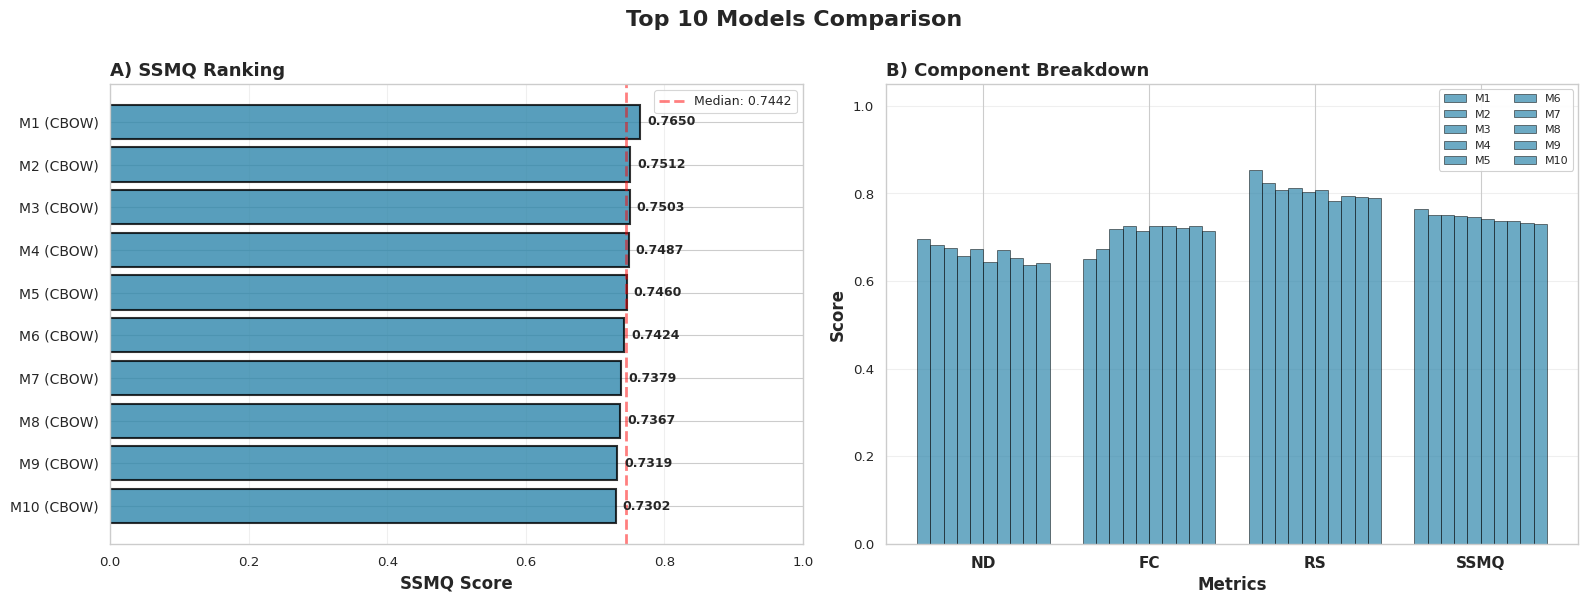

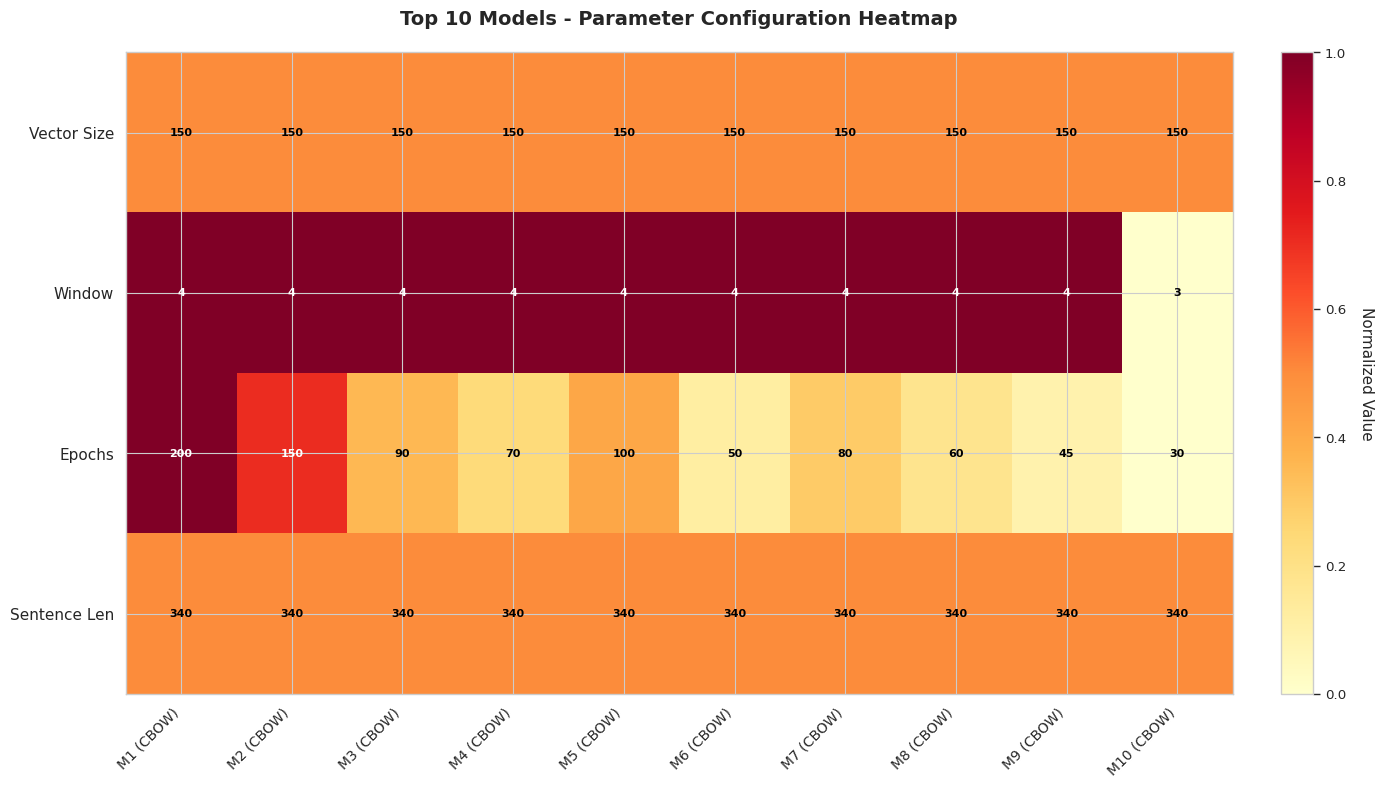


TOP 10 MODELS - SUMMARY TABLE (LaTeX-ready)

Model Algorithm   SSMQ     ND     FC     RS  Vec  Win  Epoch
   M1      CBOW 0.7650 0.6967 0.6494 0.8523  150    4    200
   M2      CBOW 0.7512 0.6815 0.6733 0.8243  150    4    150
   M3      CBOW 0.7503 0.6761 0.7193 0.8072  150    4     90
   M4      CBOW 0.7487 0.6576 0.7263 0.8122  150    4     70
   M5      CBOW 0.7460 0.6739 0.7133 0.8024  150    4    100
   M6      CBOW 0.7424 0.6430 0.7260 0.8087  150    4     50
   M7      CBOW 0.7379 0.6706 0.7254 0.7833  150    4     80
   M8      CBOW 0.7367 0.6524 0.7212 0.7935  150    4     60
   M9      CBOW 0.7319 0.6360 0.7257 0.7919  150    4     45
  M10      CBOW 0.7302 0.6409 0.7143 0.7901  150    3     30


LaTeX Table Code:
--------------------------------------------------------------------------------
\begin{tabular}{llllllrrr}
\toprule
Model & Algorithm & SSMQ & ND & FC & RS & Vec & Win & Epoch \\
\midrule
M1 & CBOW & 0.7650 & 0.6967 & 0.6494 & 0.8523 & 150 & 4 & 200 \\
M2 & CBOW

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'SSMQ': '#F18F01',
    'ND': '#6A994E',
    'FC': '#BC4B51',
    'RS': '#8B8C89'
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Sammle alle Modelle mit ihren SSMQ-Werten und Parametern
# ==================================================================================

models_list = []

for result in test_results:
    # SSMQ-Wert extrahieren
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue  # Überspringe Modelle ohne SSMQ
    
    # Parameter extrahieren
    params = result['params']
    algorithm = params.get('Algorithmus', 'Unknown')
    
    # Alle Metriken sammeln
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': algorithm,
        'vector_size': params.get('Vector Size', 'N/A'),
        'window': params.get('Window', 'N/A'),
        'epochs': params.get('Epochs', 'N/A'),
        'sentence_length': params.get('Satzlänge', 'N/A'),
        'negative': params.get('Negative Sampling', 'N/A'),
        'sample': params.get('Sample', 'N/A'),
        'alpha': params.get('Alpha', 'N/A'),
        'hs': params.get('Hierarchical Softmax', 'N/A'),
    }
    
    models_list.append(model_data)

# ==================================================================================
# SCHRITT 2: Sortiere nach SSMQ und wähle Top 10
# ==================================================================================

models_sorted = sorted(models_list, key=lambda x: x['ssmq'], reverse=True)
top10_models = models_sorted[:10]

print("\n" + "="*120)
print("TOP 10 WORD2VEC MODELS BY SSMQ SCORE")
print("="*120 + "\n")

# ==================================================================================
# SCHRITT 3: Erstelle Model-IDs und Parameter-Tabelle
# ==================================================================================

model_ids = []
model_labels = []
model_colors = []

for i, model in enumerate(top10_models, 1):
    model_id = f"M{i}"
    model_ids.append(model_id)
    
    # Farbe basierend auf Algorithmus
    color = COLORS['CBOW'] if model['algorithm'] == 'CBOW' else COLORS['SGNS']
    model_colors.append(color)
    
    # Kurze Label für Plot
    label = f"{model_id} ({model['algorithm']})"
    model_labels.append(label)

# ==================================================================================
# FIGURE 1: Metriken-Vergleich (Radar Plot Style mit Bars)
# ==================================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Models Comparison', fontsize=16, fontweight='bold', y=1.00)

# Panel A: SSMQ Ranking
ssmq_scores = [model['ssmq'] for model in top10_models]
x_pos = np.arange(len(model_ids))

bars = ax1.barh(x_pos, ssmq_scores, color=model_colors, alpha=0.8, 
                edgecolor='black', linewidth=1.5)

# Werte auf Balken
for i, (bar, score, model) in enumerate(zip(bars, ssmq_scores, top10_models)):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2., 
            f'{score:.4f}', 
            ha='left', va='center', fontsize=9, fontweight='bold')

ax1.set_yticks(x_pos)
ax1.set_yticklabels(model_labels, fontsize=10)
ax1.invert_yaxis()  # Bestes Modell oben
ax1.set_xlabel('SSMQ Score', fontsize=12, fontweight='bold')
ax1.set_title('A) SSMQ Ranking', fontsize=13, fontweight='bold', loc='left')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim([0, 1.0])

# Trennlinie bei Median
median_ssmq = np.median(ssmq_scores)
ax1.axvline(median_ssmq, color='red', linestyle='--', linewidth=2, 
           alpha=0.5, label=f'Median: {median_ssmq:.4f}')
ax1.legend(fontsize=9)

# Panel B: Component Breakdown (alle Metriken für Top 10)
metrics = ['ND', 'FC', 'RS', 'SSMQ']
x_metrics = np.arange(len(metrics))
bar_width = 0.08  # Schmale Balken für 10 Modelle

for i, model in enumerate(top10_models):
    values = [model['nd'], model['fc'], model['rs_mean'], model['ssmq']]
    offset = (i - 4.5) * bar_width  # Zentriere die Balken
    
    ax2.bar(x_metrics + offset, values, bar_width, 
           label=model_ids[i], color=model_colors[i], 
           alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('B) Component Breakdown', fontsize=13, fontweight='bold', loc='left')
ax2.set_xticks(x_metrics)
ax2.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=8, ncol=2, loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
render_figure(fig, f"Radar_Plot_{category}")


# ==================================================================================
# FIGURE 2: Detaillierte Parameter-Heatmap
# ==================================================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Erstelle Parameter-Matrix für Heatmap (ohne negative, sample, alpha)
param_names = ['Vector Size', 'Window', 'Epochs', 'Sentence Len']
param_keys = ['vector_size', 'window', 'epochs', 'sentence_length']

# Normalisiere Parameter für Heatmap (0-1 Skala)
param_matrix = []
param_raw_matrix = []

for model in top10_models:
    row = []
    raw_row = []
    for key in param_keys:
        val = model[key]
        raw_row.append(val)
        # Versuche numerischen Wert zu extrahieren
        try:
            num_val = float(val)
            row.append(num_val)
        except:
            row.append(0)
    param_matrix.append(row)
    param_raw_matrix.append(raw_row)

param_matrix = np.array(param_matrix)

# Normalisiere jede Spalte auf [0, 1]
param_matrix_norm = np.zeros_like(param_matrix)
for col in range(param_matrix.shape[1]):
    col_data = param_matrix[:, col]
    col_min = col_data.min()
    col_max = col_data.max()
    if col_max > col_min:
        param_matrix_norm[:, col] = (col_data - col_min) / (col_max - col_min)
    else:
        param_matrix_norm[:, col] = 0.5  # Alle gleich

# Erstelle Heatmap
im = ax.imshow(param_matrix_norm.T, cmap='YlOrRd', aspect='auto', 
              vmin=0, vmax=1, interpolation='nearest')

# Achsenbeschriftungen
ax.set_xticks(np.arange(len(model_ids)))
ax.set_yticks(np.arange(len(param_names)))
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(param_names, fontsize=11)

# Zeige tatsächliche Werte in Zellen
for i in range(len(model_ids)):
    for j in range(len(param_names)):
        text_val = param_raw_matrix[i][j]
        # Textfarbe basierend auf Helligkeit
        color = 'white' if param_matrix_norm[i, j] > 0.5 else 'black'
        ax.text(i, j, str(text_val), ha='center', va='center', 
               color=color, fontsize=8, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Normalized Value', rotation=270, labelpad=20, fontsize=11)

ax.set_title('Top 10 Models - Parameter Configuration Heatmap', 
            fontsize=14, fontweight='bold', pad=20)

# Trennlinie zwischen CBOW und SGNS (falls vorhanden)
cbow_count = sum(1 for m in top10_models if m['algorithm'] == 'CBOW')
if 0 < cbow_count < len(top10_models):
    ax.axvline(cbow_count - 0.5, color='blue', linewidth=3, alpha=0.6)
    ax.text(cbow_count/2 - 0.5, -0.8, 'CBOW', ha='center', fontsize=12, 
           fontweight='bold', color=COLORS['CBOW'])
    ax.text(cbow_count + (len(top10_models) - cbow_count)/2 - 0.5, -0.8, 
           'SGNS', ha='center', fontsize=12, fontweight='bold', 
           color=COLORS['SGNS'])

plt.tight_layout()
plt.show()

# ==================================================================================
# SUMMARY TABLE: Export-ready
# ==================================================================================

print("\n" + "="*120)
print("TOP 10 MODELS - SUMMARY TABLE (LaTeX-ready)")
print("="*120 + "\n")

# Erstelle DataFrame
df_data = []
for i, model in enumerate(top10_models, 1):
    df_data.append({
        'Model': f'M{i}',
        'Algorithm': model['algorithm'],
        'SSMQ': f"{model['ssmq']:.4f}",
        'ND': f"{model['nd']:.4f}",
        'FC': f"{model['fc']:.4f}",
        'RS': f"{model['rs_mean']:.4f}",
        'Vec': model['vector_size'],
        'Win': model['window'],
        'Epoch': model['epochs']
    })

df = pd.DataFrame(df_data)
print(df.to_string(index=False))
print("\n" + "="*120 + "\n")

# Optional: LaTeX Export
try:
    latex_table = df.to_latex(index=False, float_format="%.4f")
    print("LaTeX Table Code:")
    print("-" * 80)
    print(latex_table)
except:
    print("(pandas LaTeX export not available)")

print("\n" + "="*120)
print("ANALYSIS COMPLETE - Top 10 Models Identified and Visualized")
print("="*120)


SELECTED MODELS COMPARISON (2 best & 2 worst per algorithm)

BEST 2 CBOW MODELS:
  #1: CBOW | SSMQ: 0.7650 | Vec: 150, Win: 4, Epochs: 200
  #2: CBOW | SSMQ: 0.7512 | Vec: 150, Win: 4, Epochs: 150

WORST 2 CBOW MODELS:
  #1: CBOW | SSMQ: 0.4854 | Vec: 20, Win: 4, Epochs: 30
  #2: CBOW | SSMQ: 0.4713 | Vec: 60, Win: 4, Epochs: 30

BEST 2 SGNS MODELS:
  #1: SGNS | SSMQ: 0.5374 | Vec: 150, Win: 4, Epochs: 30
  #2: SGNS | SSMQ: 0.5345 | Vec: 150, Win: 1, Epochs: 30

WORST 2 SGNS MODELS:
  #1: SGNS | SSMQ: 0.3086 | Vec: 30, Win: 4, Epochs: 30
  #2: SGNS | SSMQ: 0.2620 | Vec: 20, Win: 4, Epochs: 30

EXTRACTING WORD AND SENTENCE VECTORS...

CBOW Best Models:
  Model #1:
   Total: 10053, Filtered: 10000, Kept: 53
   Sentence vectors: 30000 samples, 150 dims
   Churn: 6111 churned, 23889 not
  Model #2:
   Total: 10053, Filtered: 10000, Kept: 53
   Sentence vectors: 30000 samples, 150 dims
   Churn: 6111 churned, 23889 not

CBOW Worst Models:
  Model #1:
   Total: 10053, Filtered: 10000, Kept:

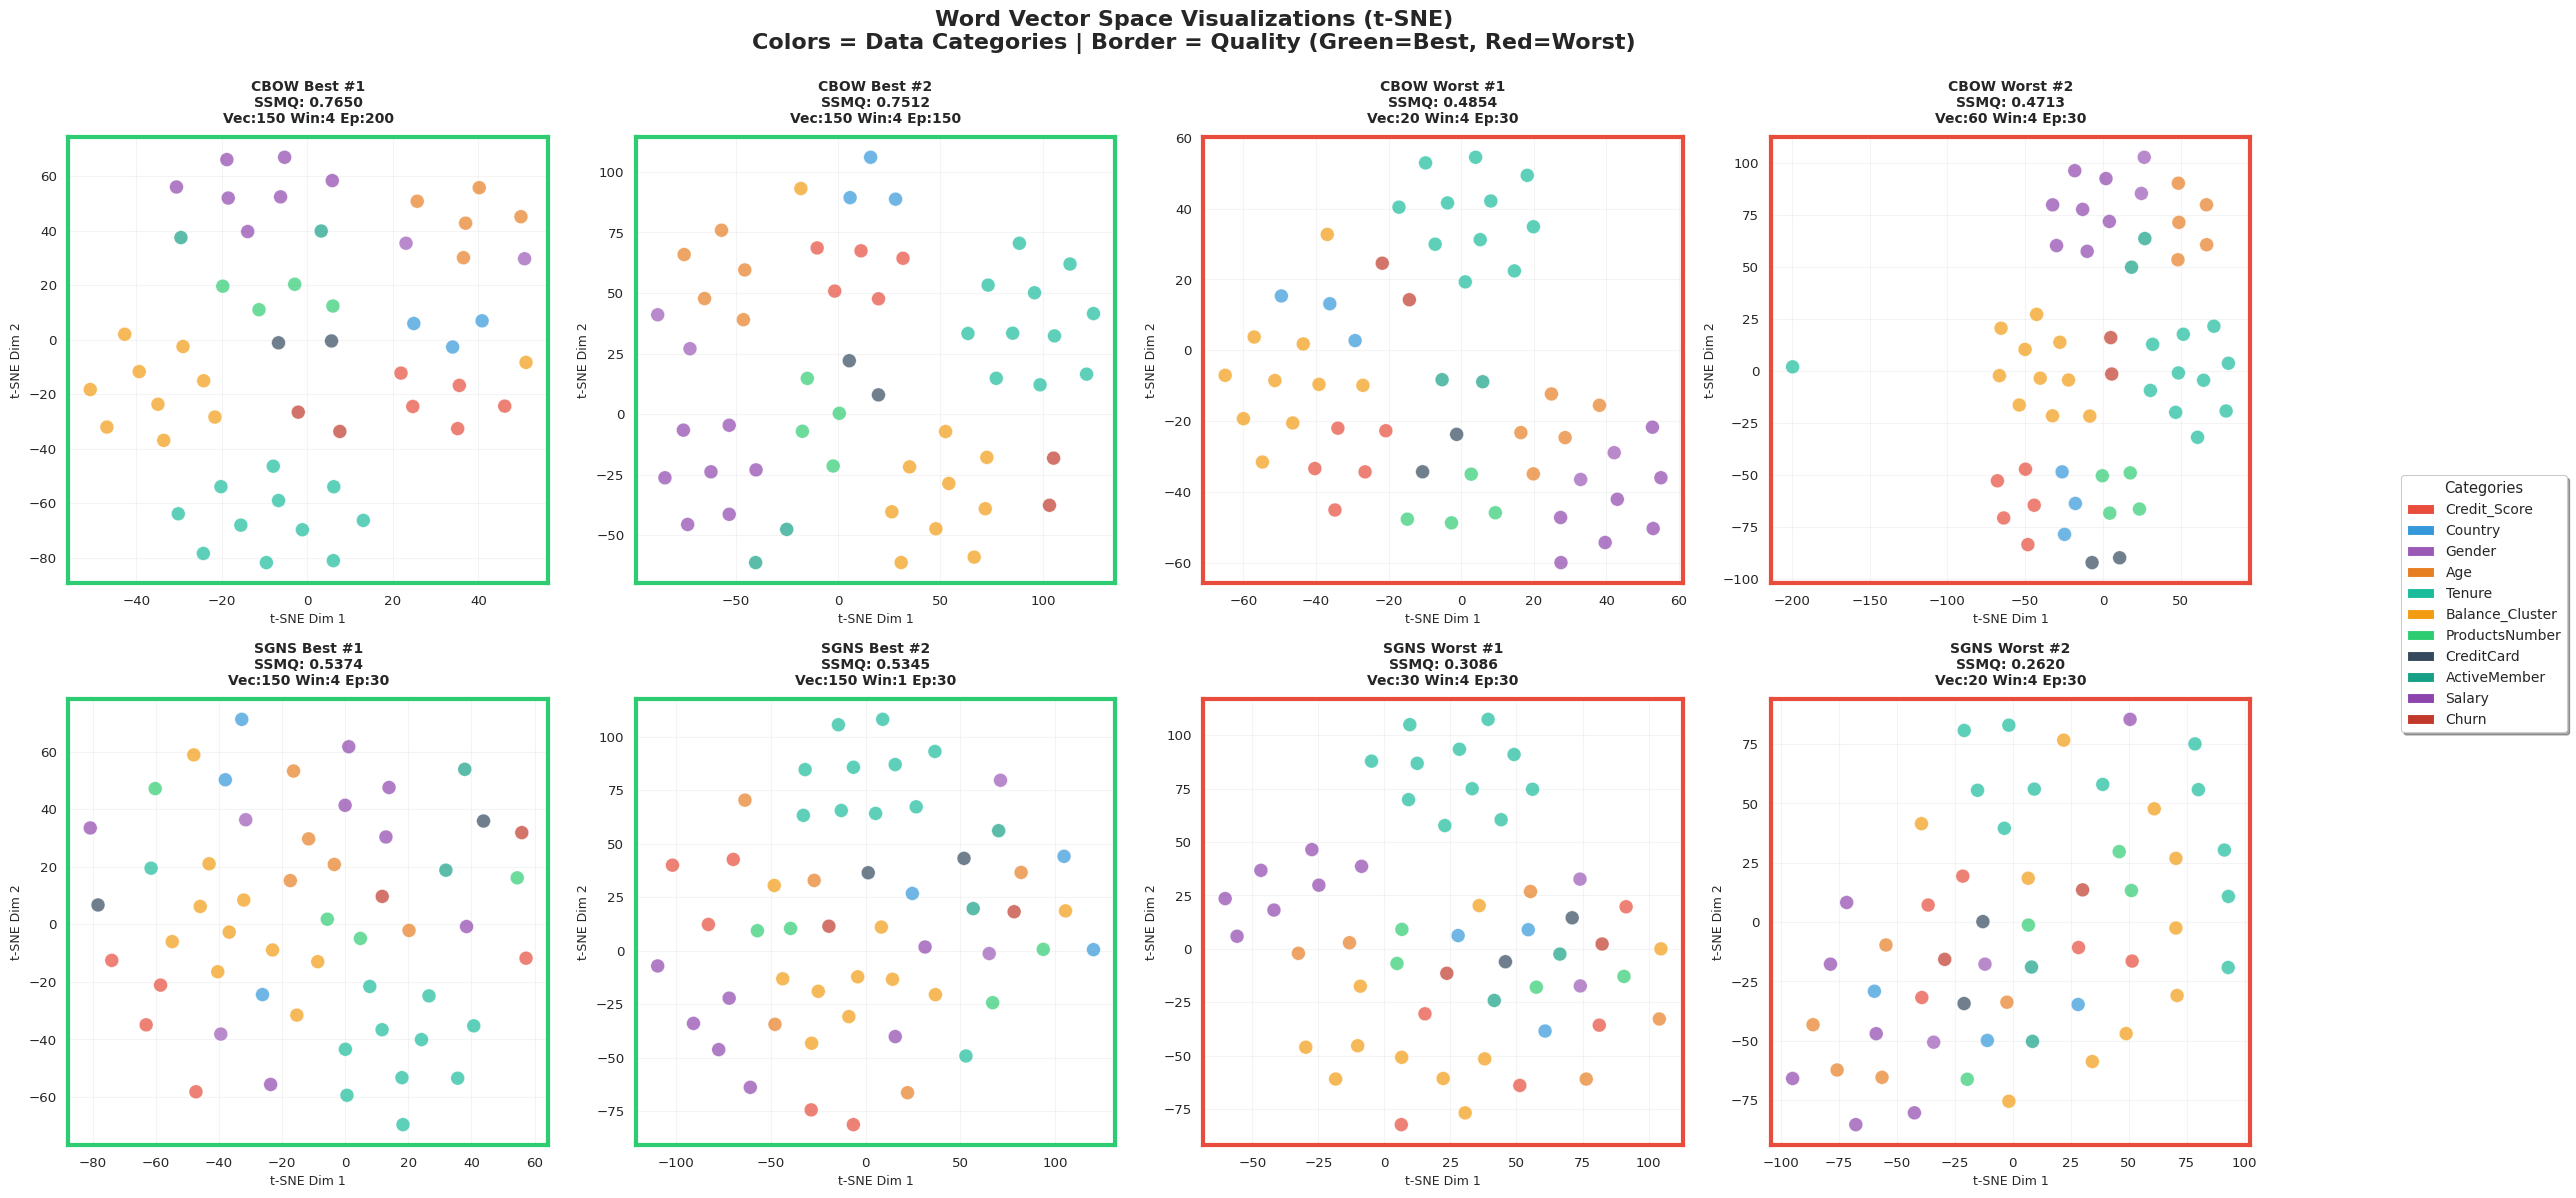


CREATING SENTENCE VECTOR VISUALIZATIONS

  CBOW Best #1: 1500 sentences
  CBOW Best #2: 1500 sentences
  CBOW Worst #1: 1500 sentences
  CBOW Worst #2: 1500 sentences
  SGNS Best #1: 1500 sentences
  SGNS Best #2: 1500 sentences
  SGNS Worst #1: 1500 sentences
  SGNS Worst #2: 1500 sentences


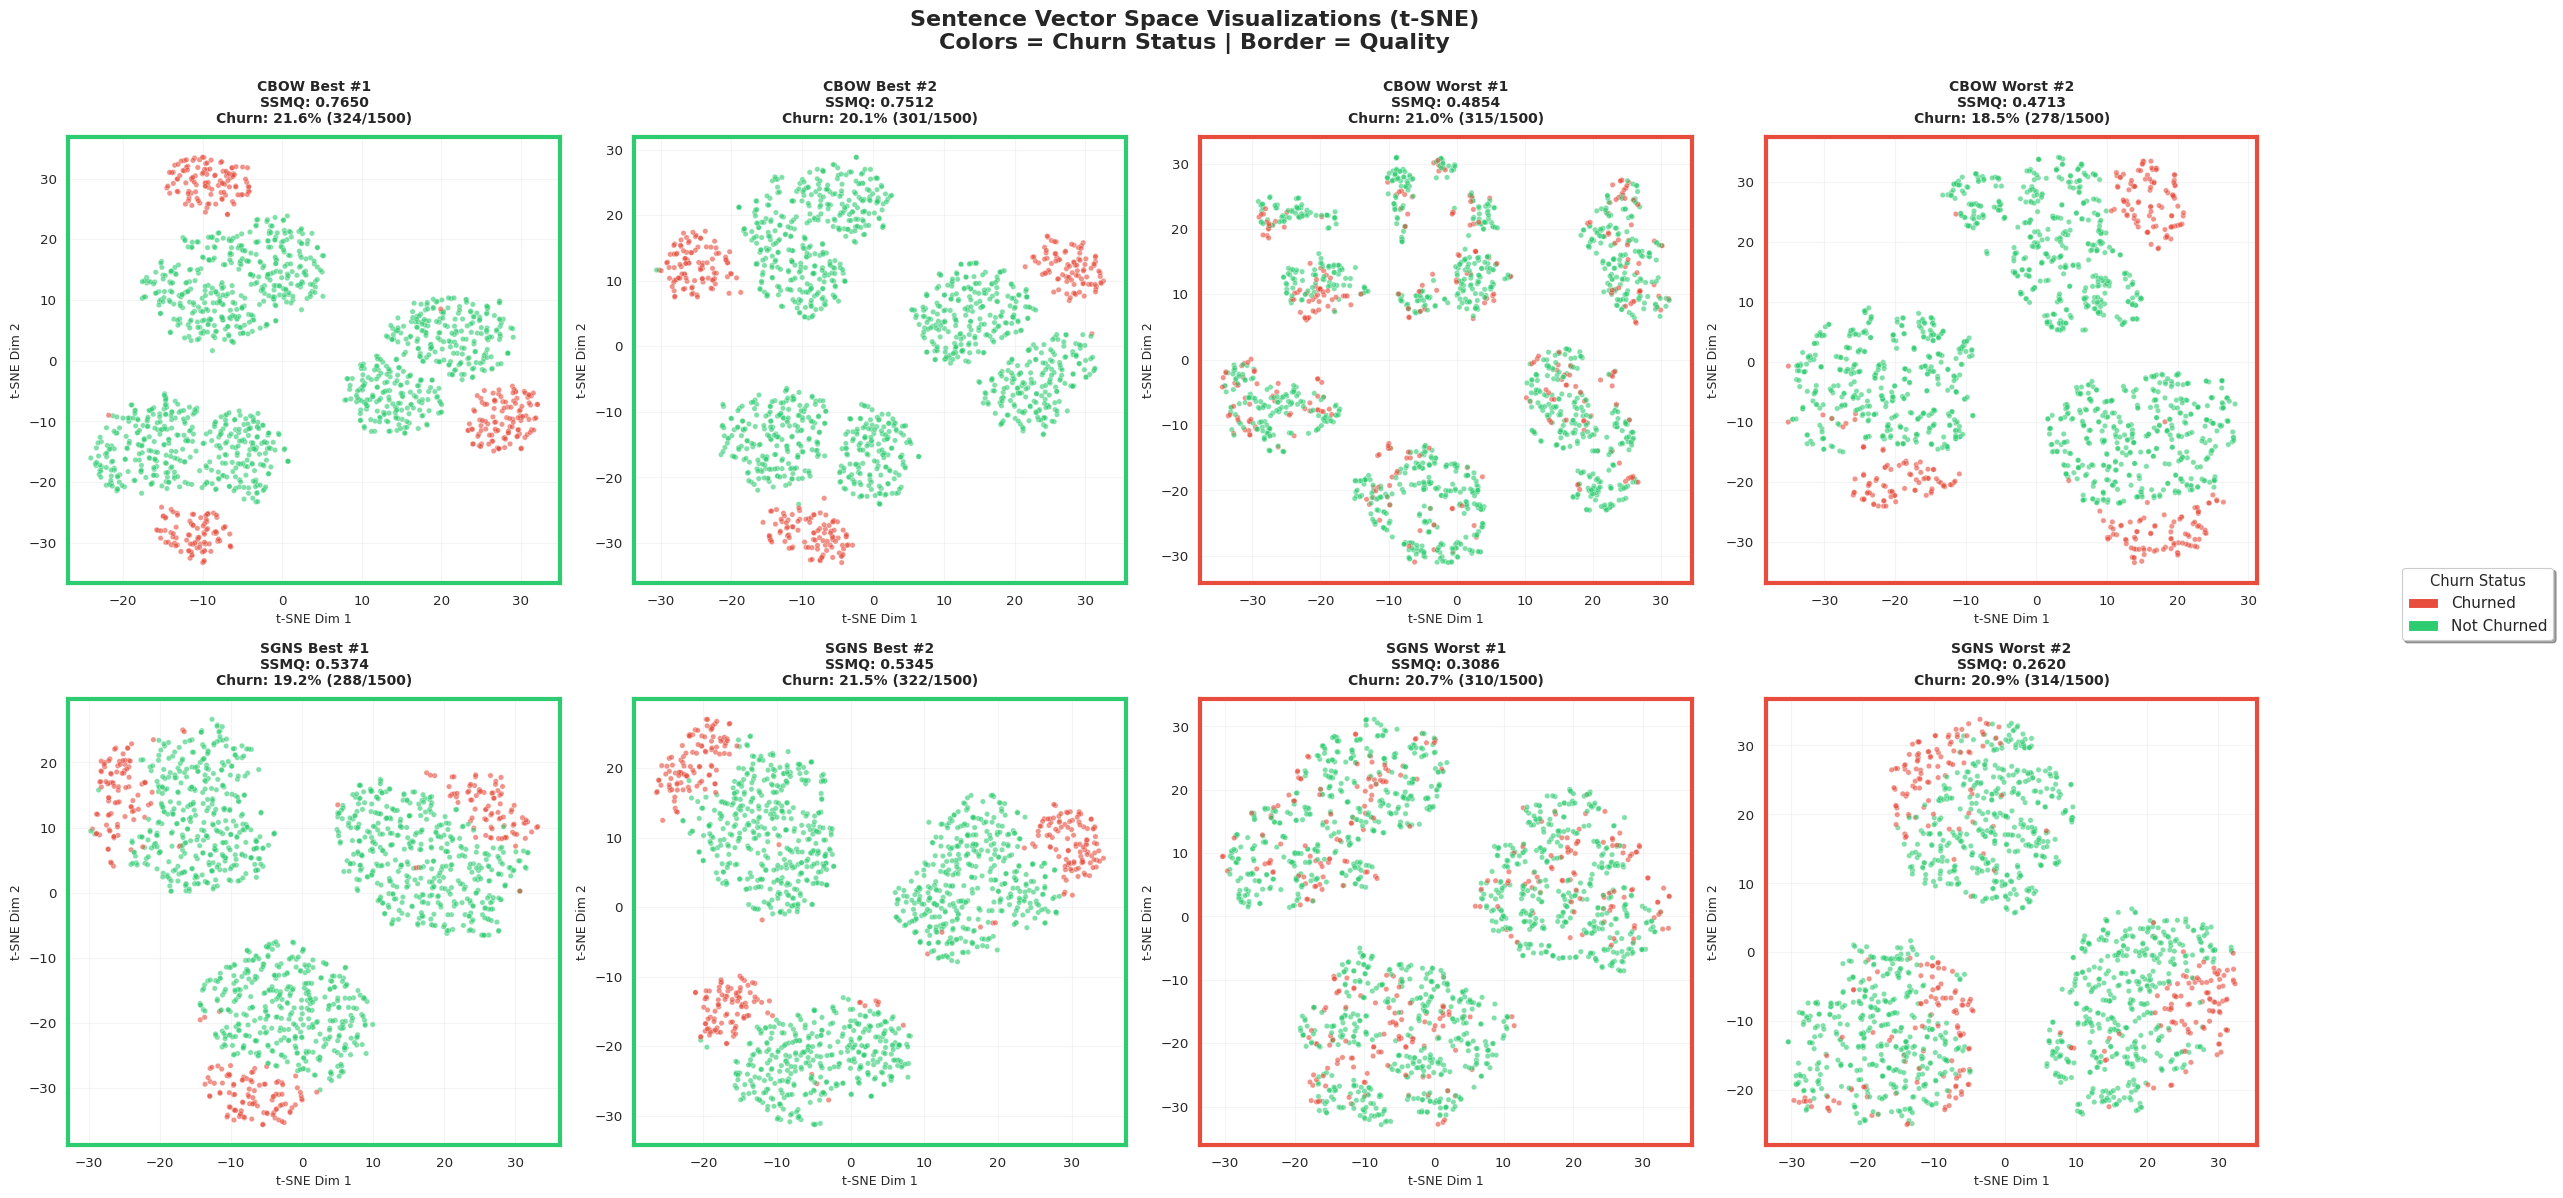

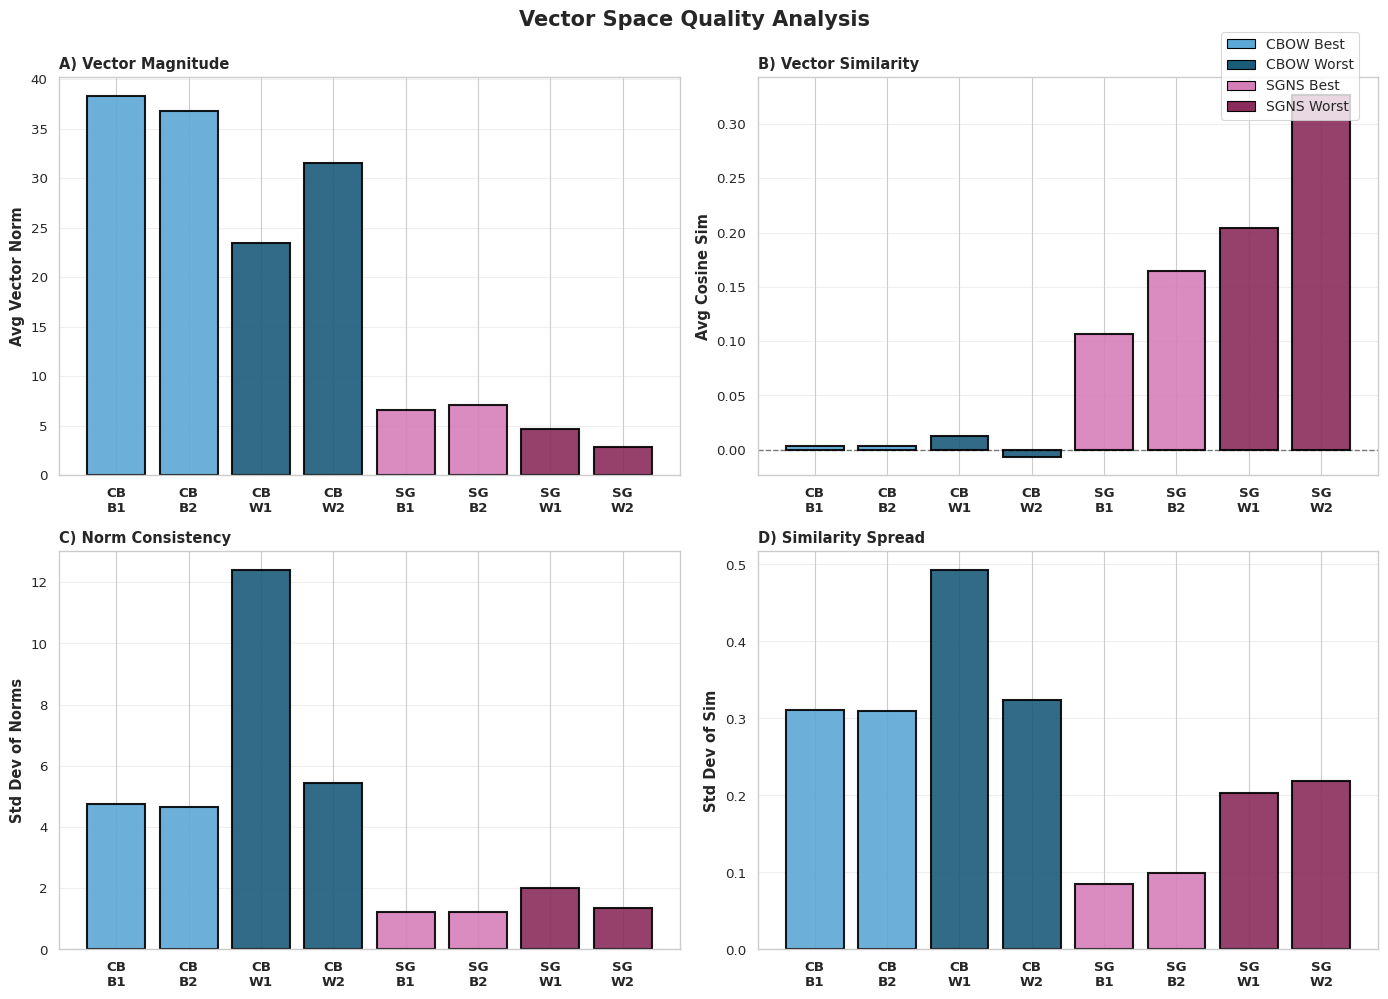


ALGORITHM COMPARISON COMPLETE


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'best': '#2ECC71',    # Grün für beste Modelle
    'worst': '#E74C3C',   # Rot für schlechteste Modelle
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Finde 2 beste und 2 schlechteste CBOW- und SGNS-Modelle
# ==================================================================================

models_list = []
for result in test_results:
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue
    
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': result['params'].get('Algorithmus', 'Unknown'),
        'vector_size': result['params'].get('Vector Size', 'N/A'),
        'window': result['params'].get('Window', 'N/A'),
        'epochs': result['params'].get('Epochs', 'N/A'),
        'result_ref': result
    }
    
    models_list.append(model_data)

# Trenne Modelle nach Algorithmus
cbow_models = [m for m in models_list if m['algorithm'].upper() == 'CBOW']
sgns_models = [m for m in models_list if m['algorithm'].upper() == 'SGNS']

# Sortiere nach SSMQ (absteigend)
cbow_sorted = sorted(cbow_models, key=lambda x: x['ssmq'], reverse=True)
sgns_sorted = sorted(sgns_models, key=lambda x: x['ssmq'], reverse=True)

# Wähle 2 beste und 2 schlechteste für jeden Algorithmus
best_2_cbow = cbow_sorted[:2]
worst_2_cbow = cbow_sorted[-2:] if len(cbow_sorted) >= 2 else []
best_2_sgns = sgns_sorted[:2]
worst_2_sgns = sgns_sorted[-2:] if len(sgns_sorted) >= 2 else []

print("\n" + "="*100)
print("SELECTED MODELS COMPARISON (2 best & 2 worst per algorithm)")
print("="*100 + "\n")

print("BEST 2 CBOW MODELS:")
for i, model in enumerate(best_2_cbow, 1):
    print(f"  #{i}: CBOW | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nWORST 2 CBOW MODELS:")
for i, model in enumerate(worst_2_cbow, 1):
    print(f"  #{i}: CBOW | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nBEST 2 SGNS MODELS:")
for i, model in enumerate(best_2_sgns, 1):
    print(f"  #{i}: SGNS | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nWORST 2 SGNS MODELS:")
for i, model in enumerate(worst_2_sgns, 1):
    print(f"  #{i}: SGNS | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

# ==================================================================================
# HILFSFUNKTIONEN
# ==================================================================================

def extract_word_vectors(model_data):
    """Extrahiert Word Vectors und filtert key_* Wörter"""
    result = model_data['result_ref']
    
    if 'used_model' in result and 'model_object' in result['used_model']:
        model = result['used_model']['model_object']
        
        if hasattr(model, 'wv'):
            all_vocab = list(model.wv.key_to_index.keys())
            filtered_vocab = [word for word in all_vocab if 'key_' not in word.lower()]
            
            if len(filtered_vocab) == 0:
                print(f"⚠️ Alle Wörter wurden gefiltert")
                return None, None
            
            filtered_indices = [model.wv.key_to_index[word] for word in filtered_vocab]
            filtered_vectors = model.wv.vectors[filtered_indices]
            
            filtered_count = len(all_vocab) - len(filtered_vocab)
            print(f"   Total: {len(all_vocab)}, Filtered: {filtered_count}, Kept: {len(filtered_vocab)}")
            
            return filtered_vectors, filtered_vocab
    
    print(f"⚠️ Keine Vektoren gefunden")
    return None, None


def extract_sentence_vectors(model_data):
    """Extrahiert Satzvektoren und Churn-Labels"""
    result = model_data['result_ref']
    
    if 'used_sentence_vectors' in result and 'data' in result['used_sentence_vectors']:
        data_tuples = result['used_sentence_vectors']['data']
        
        if not data_tuples:
            print(f"   No sentence vectors found")
            return None, None
        
        all_vectors = []
        all_labels = []
        
        for seed_id, df in data_tuples:
            vectors = np.array([np.array(v) for v in df['vector'].values])
            labels = df['churned'].values
            all_vectors.append(vectors)
            all_labels.append(labels)
        
        combined_vectors = np.vstack(all_vectors)
        combined_labels = np.concatenate(all_labels)
        
        print(f"   Sentence vectors: {combined_vectors.shape[0]} samples, {combined_vectors.shape[1]} dims")
        print(f"   Churn: {np.sum(combined_labels)} churned, {len(combined_labels) - np.sum(combined_labels)} not")
        
        return combined_vectors, combined_labels
    
    print(f"   No sentence vectors available")
    return None, None


def get_category_color(word):
    """Bestimmt Farbe basierend auf Datenkategorie"""
    category_colors = {
        'Credit_Score': '#E74C3C',
        'Country': '#3498DB',
        'Gender': '#9B59B6',
        'Age': '#E67E22',
        'Tenure': '#1ABC9C',
        'Balance_Cluster': '#F39C12',
        'ProductsNumber': '#2ECC71',
        'CreditCard': '#34495E',
        'ActiveMember': '#16A085',
        'Salary': '#8E44AD',
        'Churn': '#C0392B',
    }
    
    parts = word.split('_')
    
    if len(parts) >= 2 and parts[0] == 'Balance' and parts[1] == 'Cluster':
        category = 'Balance_Cluster'
    elif len(parts) >= 1:
        category = parts[0]
        if len(parts) >= 2 and f"{parts[0]}_{parts[1]}" in category_colors:
            category = f"{parts[0]}_{parts[1]}"
    else:
        category = None
    
    return category_colors.get(category, '#95A5A6')


def compute_vector_statistics(vectors):
    """Berechnet Statistiken über den Vektorraum"""
    norms = np.linalg.norm(vectors, axis=1)
    avg_norm = np.mean(norms)
    std_norm = np.std(norms)
    
    sample_size = min(1000, len(vectors))
    sample_indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[sample_indices]
    
    sample_vectors_norm = sample_vectors / (np.linalg.norm(sample_vectors, axis=1, keepdims=True) + 1e-8)
    similarity_matrix = np.dot(sample_vectors_norm, sample_vectors_norm.T)
    
    mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
    avg_similarity = np.mean(similarity_matrix[mask])
    std_similarity = np.std(similarity_matrix[mask])
    
    return {
        'avg_norm': avg_norm,
        'std_norm': std_norm,
        'avg_similarity': avg_similarity,
        'std_similarity': std_similarity
    }

# ==================================================================================
# DATENEXTRAKTION
# ==================================================================================

# Listen für Word Vectors
cbow_best_vectors, cbow_worst_vectors = [], []
sgns_best_vectors, sgns_worst_vectors = [], []
cbow_best_vocab, cbow_worst_vocab = [], []
sgns_best_vocab, sgns_worst_vocab = [], []

# Listen für Sentence Vectors
cbow_best_sent_vectors, cbow_worst_sent_vectors = [], []
sgns_best_sent_vectors, sgns_worst_sent_vectors = [], []
cbow_best_sent_labels, cbow_worst_sent_labels = [], []
sgns_best_sent_labels, sgns_worst_sent_labels = [], []

print("\n" + "="*100)
print("EXTRACTING WORD AND SENTENCE VECTORS...")
print("="*100 + "\n")

# CBOW Best
print("CBOW Best Models:")
for i, model in enumerate(best_2_cbow):
    print(f"  Model #{i+1}:")
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        cbow_best_vectors.append(vectors)
        cbow_best_vocab.append(vocab)
    
    sent_vec, sent_lab = extract_sentence_vectors(model)
    if sent_vec is not None:
        cbow_best_sent_vectors.append(sent_vec)
        cbow_best_sent_labels.append(sent_lab)

# CBOW Worst
print("\nCBOW Worst Models:")
for i, model in enumerate(worst_2_cbow):
    print(f"  Model #{i+1}:")
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        cbow_worst_vectors.append(vectors)
        cbow_worst_vocab.append(vocab)
    
    sent_vec, sent_lab = extract_sentence_vectors(model)
    if sent_vec is not None:
        cbow_worst_sent_vectors.append(sent_vec)
        cbow_worst_sent_labels.append(sent_lab)

# SGNS Best
print("\nSGNS Best Models:")
for i, model in enumerate(best_2_sgns):
    print(f"  Model #{i+1}:")
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        sgns_best_vectors.append(vectors)
        sgns_best_vocab.append(vocab)
    
    sent_vec, sent_lab = extract_sentence_vectors(model)
    if sent_vec is not None:
        sgns_best_sent_vectors.append(sent_vec)
        sgns_best_sent_labels.append(sent_lab)

# SGNS Worst
print("\nSGNS Worst Models:")
for i, model in enumerate(worst_2_sgns):
    print(f"  Model #{i+1}:")
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        sgns_worst_vectors.append(vectors)
        sgns_worst_vocab.append(vocab)
    
    sent_vec, sent_lab = extract_sentence_vectors(model)
    if sent_vec is not None:
        sgns_worst_sent_vectors.append(sent_vec)
        sgns_worst_sent_labels.append(sent_lab)

# ==================================================================================
# FIGURE 1: WORD VECTORS (8 Plots)
# ==================================================================================

all_word_plots = []

for i in range(min(2, len(cbow_best_vectors))):
    all_word_plots.append({
        'vectors': cbow_best_vectors[i], 'vocab': cbow_best_vocab[i],
        'model_info': best_2_cbow[i], 'algorithm': 'CBOW', 'quality': 'Best',
        'rank': i + 1, 'border_color': COLORS['best']
    })

for i in range(min(2, len(cbow_worst_vectors))):
    all_word_plots.append({
        'vectors': cbow_worst_vectors[i], 'vocab': cbow_worst_vocab[i],
        'model_info': worst_2_cbow[i], 'algorithm': 'CBOW', 'quality': 'Worst',
        'rank': i + 1, 'border_color': COLORS['worst']
    })

for i in range(min(2, len(sgns_best_vectors))):
    all_word_plots.append({
        'vectors': sgns_best_vectors[i], 'vocab': sgns_best_vocab[i],
        'model_info': best_2_sgns[i], 'algorithm': 'SGNS', 'quality': 'Best',
        'rank': i + 1, 'border_color': COLORS['best']
    })

for i in range(min(2, len(sgns_worst_vectors))):
    all_word_plots.append({
        'vectors': sgns_worst_vectors[i], 'vocab': sgns_worst_vocab[i],
        'model_info': worst_2_sgns[i], 'algorithm': 'SGNS', 'quality': 'Worst',
        'rank': i + 1, 'border_color': COLORS['worst']
    })

if all_word_plots:
    print(f"\n{'='*100}")
    print("CREATING WORD VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle('Word Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Data Categories | Border = Quality (Green=Best, Red=Worst)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    
    for idx, model_data in enumerate(all_word_plots):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        vocab = model_data['vocab']
        model_info = model_data['model_info']
        
        max_words = min(2000, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_words, replace=False)
        vectors_sample = vectors[sample_indices]
        vocab_sample = [vocab[i] for i in sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']} #{model_data['rank']}: {max_words} words")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_words-1), 
                   max_iter=5000, n_iter_without_progress=300, early_exaggeration=12.0, 
                   learning_rate=240, metric='cosine')
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        point_colors = [get_category_color(word) for word in vocab_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.7, s=100, edgecolors='white', linewidth=0.4)
        
        title = f"{model_data['algorithm']} {model_data['quality']} #{model_data['rank']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Vec:{model_info['vector_size']} Win:{model_info['window']} Ep:{model_info['epochs']}"
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=9)
        ax.set_ylabel('t-SNE Dim 2', fontsize=9)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    for idx in range(len(all_word_plots), len(axes)):
        axes[idx].set_visible(False)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Credit_Score'),
        Patch(facecolor='#3498DB', label='Country'),
        Patch(facecolor='#9B59B6', label='Gender'),
        Patch(facecolor='#E67E22', label='Age'),
        Patch(facecolor='#1ABC9C', label='Tenure'),
        Patch(facecolor='#F39C12', label='Balance_Cluster'),
        Patch(facecolor='#2ECC71', label='ProductsNumber'),
        Patch(facecolor='#34495E', label='CreditCard'),
        Patch(facecolor='#16A085', label='ActiveMember'),
        Patch(facecolor='#8E44AD', label='Salary'),
        Patch(facecolor='#C0392B', label='Churn'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.0, 0.5), fontsize=10, title='Categories',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    render_figure(fig, f"Word_Vectors_{category}")

# ==================================================================================
# FIGURE 2: SENTENCE VECTORS (8 Plots)
# ==================================================================================

all_sent_plots = []

for i in range(len(cbow_best_sent_vectors)):
    all_sent_plots.append({
        'vectors': cbow_best_sent_vectors[i], 'labels': cbow_best_sent_labels[i],
        'model_info': best_2_cbow[i], 'algorithm': 'CBOW', 'quality': 'Best',
        'rank': i + 1, 'border_color': COLORS['best']
    })

for i in range(len(cbow_worst_sent_vectors)):
    all_sent_plots.append({
        'vectors': cbow_worst_sent_vectors[i], 'labels': cbow_worst_sent_labels[i],
        'model_info': worst_2_cbow[i], 'algorithm': 'CBOW', 'quality': 'Worst',
        'rank': i + 1, 'border_color': COLORS['worst']
    })

for i in range(len(sgns_best_sent_vectors)):
    all_sent_plots.append({
        'vectors': sgns_best_sent_vectors[i], 'labels': sgns_best_sent_labels[i],
        'model_info': best_2_sgns[i], 'algorithm': 'SGNS', 'quality': 'Best',
        'rank': i + 1, 'border_color': COLORS['best']
    })

for i in range(len(sgns_worst_sent_vectors)):
    all_sent_plots.append({
        'vectors': sgns_worst_sent_vectors[i], 'labels': sgns_worst_sent_labels[i],
        'model_info': worst_2_sgns[i], 'algorithm': 'SGNS', 'quality': 'Worst',
        'rank': i + 1, 'border_color': COLORS['worst']
    })

if all_sent_plots:
    print(f"\n{'='*100}")
    print("CREATING SENTENCE VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle('Sentence Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Churn Status | Border = Quality', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    churn_colors = {True: '#E74C3C', False: '#2ECC71'}
    
    for idx, model_data in enumerate(all_sent_plots):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        labels = model_data['labels']
        model_info = model_data['model_info']
        
        max_sent = min(1500, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_sent, replace=False)
        vectors_sample = vectors[sample_indices]
        labels_sample = labels[sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']} #{model_data['rank']}: {max_sent} sentences")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_sent-1), 
                   max_iter=500)
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        point_colors = [churn_colors[label] for label in labels_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.6, s=15, edgecolors='white', linewidth=0.3)
        
        churn_count = np.sum(labels_sample)
        churn_rate = churn_count / len(labels_sample)
        
        title = f"{model_data['algorithm']} {model_data['quality']} #{model_data['rank']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Churn: {churn_rate:.1%} ({churn_count}/{len(labels_sample)})"
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=9)
        ax.set_ylabel('t-SNE Dim 2', fontsize=9)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    for idx in range(len(all_sent_plots), len(axes)):
        axes[idx].set_visible(False)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=churn_colors[True], label='Churned'),
        Patch(facecolor=churn_colors[False], label='Not Churned'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.0, 0.5), fontsize=11, title='Churn Status',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    render_figure(fig, f"Sentence_Vectors_{category}")

# ==================================================================================
# FIGURE 3: VECTOR SPACE QUALITY METRICS
# ==================================================================================

all_stats = []
all_labels = []

for i, vec in enumerate(cbow_best_vectors):
    all_stats.append(compute_vector_statistics(vec))
    all_labels.append(f'CB-B{i+1}')

for i, vec in enumerate(cbow_worst_vectors):
    all_stats.append(compute_vector_statistics(vec))
    all_labels.append(f'CB-W{i+1}')

for i, vec in enumerate(sgns_best_vectors):
    all_stats.append(compute_vector_statistics(vec))
    all_labels.append(f'SG-B{i+1}')

for i, vec in enumerate(sgns_worst_vectors):
    all_stats.append(compute_vector_statistics(vec))
    all_labels.append(f'SG-W{i+1}')

if all_stats:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Vector Space Quality Analysis', fontsize=15, fontweight='bold', y=0.995)
    
    bar_colors = []
    for label in all_labels:
        if label.startswith('CB-B'):
            bar_colors.append('#5CA8D6')
        elif label.startswith('CB-W'):
            bar_colors.append('#1A5B7A')
        elif label.startswith('SG-B'):
            bar_colors.append('#D67EB8')
        elif label.startswith('SG-W'):
            bar_colors.append('#8A2C5C')
    
    xtick_labels = []
    for label in all_labels:
        algo = "CBOW" if label.startswith('CB') else "SGNS"
        quality = "B" if 'B' in label[-2] else "W"
        num = label[-1]
        xtick_labels.append(f"{algo[:2]}\n{quality}{num}")
    
    # Plot metrics
    axes[0, 0].bar(all_labels, [s['avg_norm'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_title('A) Vector Magnitude', fontweight='bold', loc='left')
    axes[0, 0].set_ylabel('Avg Vector Norm', fontweight='bold')
    axes[0, 0].set_xticks(range(len(all_labels)))
    axes[0, 0].set_xticklabels(xtick_labels, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    axes[0, 1].bar(all_labels, [s['avg_similarity'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_title('B) Vector Similarity', fontweight='bold', loc='left')
    axes[0, 1].set_ylabel('Avg Cosine Sim', fontweight='bold')
    axes[0, 1].set_xticks(range(len(all_labels)))
    axes[0, 1].set_xticklabels(xtick_labels, fontweight='bold')
    axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    axes[1, 0].bar(all_labels, [s['std_norm'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5)
    axes[1, 0].set_title('C) Norm Consistency', fontweight='bold', loc='left')
    axes[1, 0].set_ylabel('Std Dev of Norms', fontweight='bold')
    axes[1, 0].set_xticks(range(len(all_labels)))
    axes[1, 0].set_xticklabels(xtick_labels, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    axes[1, 1].bar(all_labels, [s['std_similarity'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5)
    axes[1, 1].set_title('D) Similarity Spread', fontweight='bold', loc='left')
    axes[1, 1].set_ylabel('Std Dev of Sim', fontweight='bold')
    axes[1, 1].set_xticks(range(len(all_labels)))
    axes[1, 1].set_xticklabels(xtick_labels, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#5CA8D6', edgecolor='black', label='CBOW Best'),
        Patch(facecolor='#1A5B7A', edgecolor='black', label='CBOW Worst'),
        Patch(facecolor='#D67EB8', edgecolor='black', label='SGNS Best'),
        Patch(facecolor='#8A2C5C', edgecolor='black', label='SGNS Worst')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
              bbox_to_anchor=(0.98, 0.98))
    
    plt.tight_layout()
    render_figure(fig, f"Vector_Space_Metrics_{category}")

print("\n" + "="*100)
print("ALGORITHM COMPARISON COMPLETE")
print("="*100)